# Projet Bloc IA — Analyse du Turnover chez HumanForYou

**Groupe C** : Maxence Chartier, Amine Haouri, Anisse Imerzoukene, Mourad Messaoudi

---

## Contexte

L'entreprise **HumanForYou**, acteur du secteur des ressources humaines basé en Inde, fait face à un taux de turnover préoccupant. La direction souhaite exploiter les données RH disponibles pour **comprendre les facteurs de départ** et **anticiper les risques d'attrition**.

## Objectifs

1. **Explorer et préparer les données** issues de quatre sources distinctes (données générales, enquêtes employés, évaluations managériales, horaires de badgeage)
2. **Construire des modèles prédictifs** de l'attrition (régression et classification)
3. **Formuler des recommandations** concrètes et actionnables à destination de la direction

## Données disponibles

| Fichier | Description |
|---|---|
| `general_data.csv` | Informations démographiques, professionnelles et salariales (4 410 employés, 24 colonnes) |
| `employee_survey_data.csv` | Enquête de satisfaction des employés |
| `manager_survey_data.csv` | Évaluations managériales |
| `in_time.csv` / `out_time.csv` | Horaires de badgeage (entrée/sortie) |

**Variable cible** : `Attrition` — l'employé a-t-il quitté l'entreprise ?

## Plan du notebook

1. **Fusion des datasets** — Chargement des 4 sources, agrégation des données de badgeage, jointures successives et construction du DataFrame unifié
2. **Prétraitement des données** — Imputation des valeurs manquantes, détection et traitement des outliers, encodage et normalisation
3. **Modèle 1 : Régression Logistique** — Baseline interprétable avec analyse de multicolinéarité
4. **Modèle 2 : Random Forest** — Ensemble d'arbres de décision avec feature importance
5. **Modèle 3 : MLP (Perceptron Multi-Couches)** — Réseau de neurones pour les relations non-linéaires
6. **Comparaison des modèles** — Évaluation croisée, métriques, courbes ROC et recommandation finale
7. **Explicabilité (SHAP)** — Comprendre *pourquoi* un employé est prédit à risque : explicabilité globale et individuelle
8. **Audit d'équité et conformité éthique** — Vérification des biais sur les attributs protégés (Genre, Âge, Statut marital) et conformité aux 7 principes HLEG
9. **Évaluation finale et recommandation** — Tableau de scores comparatif, évaluation de l'explicabilité, recommandation du modèle et pistes d'amélioration pour HumanForYou

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# 1. Fusion des datasets — Construction du DataFrame unifié

Ce notebook montre comment relier les 4 sources de données entre elles
via la clé commune `EmployeeID` et produit un DataFrame final prêt à l'analyse.

## Schéma des liens entre datasets

```
                         ┌─────────────────────────┐
                         │   general_data.csv      │
                         │   (24 colonnes)         │
                         │   Clé : EmployeeID      │
                         └────────┬────────────────┘
                                  │
                    EmployeeID (inner join)
                 ┌────────────────┼────────────────┐
                 │                │                 │
    ┌────────────▼──────┐  ┌─────▼──────────┐  ┌──▼──────────────────┐
    │ employee_survey   │  │ manager_survey │  │ in_out_time/        │
    │ _data.csv         │  │ _data.csv      │  │ (in_time, out_time) │
    │                   │  │                │  │                     │
    │ Clé: EmployeeID   │  │ Clé: EmployeeID│  │ Clé: index (=EmpID)│
    │ 3 cols satisfaction│  │ 2 cols évaluat.│  │ → agrégé en 6 cols │
    └───────────────────┘  └────────────────┘  └─────────────────────┘
```

**Type de jointure** : toutes les jointures se font sur `EmployeeID` :
- **general_data** ↔ **employee_survey** : relation 1:1 via `EmployeeID`
- **general_data** ↔ **manager_survey** : relation 1:1 via `EmployeeID`
- **general_data** ↔ **in_out_time** : relation 1:1 via `EmployeeID` (index des fichiers CSV)

Les 4 fichiers contiennent exactement les mêmes 4410 employés.

## 1.1 Chargement de tous les datasets

In [2]:
# 1. Données RH générales
df_general = pd.read_csv("data/general_data.csv")
print(f"general_data       : {df_general.shape}")

# 2. Enquête employé
df_emp_survey = pd.read_csv("data/employee_survey_data.csv")
print(f"employee_survey    : {df_emp_survey.shape}")

# 3. Évaluation manager
df_mgr_survey = pd.read_csv("data/manager_survey_data.csv")
print(f"manager_survey     : {df_mgr_survey.shape}")

# 4. Horaires de badgeage → agrégation
df_in = pd.read_csv("data/in_out_time/in_time.csv", index_col=0)
df_out = pd.read_csv("data/in_out_time/out_time.csv", index_col=0)
print(f"in_time            : {df_in.shape}")
print(f"out_time           : {df_out.shape}")

general_data       : (4410, 24)
employee_survey    : (4410, 4)
manager_survey     : (4410, 3)
in_time            : (4410, 261)
out_time           : (4410, 261)


## 1.2 Vérification de la cohérence des `EmployeeID`

Avant toute jointure, on vérifie que les 4 sources couvrent les mêmes employés.

In [3]:
ids_general = set(df_general["EmployeeID"])
ids_emp = set(df_emp_survey["EmployeeID"])
ids_mgr = set(df_mgr_survey["EmployeeID"])
ids_time = set(df_in.index)

all_ids = [ids_general, ids_emp, ids_mgr, ids_time]
names = ["general_data", "employee_survey", "manager_survey", "in_out_time"]

print("Nombre d'EmployeeID par source :")
for name, ids in zip(names, all_ids):
    print(f"  {name:20s} : {len(ids)}")

common = ids_general & ids_emp & ids_mgr & ids_time
print(f"\nIntersection (présents partout) : {len(common)}")
print(f"Union totale                    : {len(ids_general | ids_emp | ids_mgr | ids_time)}")

Nombre d'EmployeeID par source :
  general_data         : 4410
  employee_survey      : 4410
  manager_survey       : 4410
  in_out_time          : 4410

Intersection (présents partout) : 4410
Union totale                    : 4410


## 1.3 Agrégation des données de badgeage

Les fichiers `in_time` / `out_time` contiennent 261 colonnes-dates.
On les agrège en indicateurs par employé avant la jointure.

In [4]:
# Conversion en datetime
df_in_dt = df_in.apply(pd.to_datetime, errors="coerce")
df_out_dt = df_out.apply(pd.to_datetime, errors="coerce")

# Durée de travail en heures
df_duration = (df_out_dt - df_in_dt).apply(lambda col: col.dt.total_seconds() / 3600)

# Heures d'arrivée et de départ
df_in_hours = df_in_dt.apply(lambda col: col.dt.hour + col.dt.minute / 60)
df_out_hours = df_out_dt.apply(lambda col: col.dt.hour + col.dt.minute / 60)

# Construction du DataFrame agrégé
df_time_features = pd.DataFrame({
    "EmployeeID": df_in.index,
    "avg_in_hour": df_in_hours.mean(axis=1).values,
    "avg_out_hour": df_out_hours.mean(axis=1).values,
    "avg_work_hours": df_duration.mean(axis=1).values,
    "std_work_hours": df_duration.std(axis=1).values,
    "nb_days_present": df_duration.notna().sum(axis=1).values,
    "nb_days_absent": df_duration.isna().sum(axis=1).values,
})

print(f"Features temporelles : {df_time_features.shape}")
df_time_features.head()

Features temporelles : (4410, 7)


,EmployeeID,avg_in_hour,avg_out_hour,avg_work_hours,std_work_hours,nb_days_present,nb_days_absent
0,1,9.993032,17.367170,7.373651,0.283224,232,29
1,2,9.980720,17.698446,7.718969,0.313351,236,25
2,3,10.016598,17.030096,7.013240,0.311551,242,19
3,4,9.973830,17.167305,7.193678,0.284133,235,26
4,5,9.990068,17.996327,8.006175,0.300656,245,16


## 1.4 Jointures successives

On fusionne les 4 sources étape par étape via `pd.merge()` sur `EmployeeID`.
On utilise un **left join** en partant de `general_data` (table de référence)
pour conserver tous les employés même en cas de données manquantes dans les enquêtes.

In [5]:
# Étape 1 : general_data + employee_survey
df = df_general.merge(df_emp_survey, on="EmployeeID", how="left")
print(f"Après merge general + employee_survey : {df.shape}")

# Étape 2 : + manager_survey
df = df.merge(df_mgr_survey, on="EmployeeID", how="left")
print(f"Après merge + manager_survey          : {df.shape}")

# Étape 3 : + features temporelles (badgeage)
df = df.merge(df_time_features, on="EmployeeID", how="left")
print(f"Après merge + time_features           : {df.shape}")

Après merge general + employee_survey : (4410, 27)
Après merge + manager_survey          : (4410, 29)
Après merge + time_features           : (4410, 35)


In [6]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,avg_in_hour,avg_out_hour,avg_work_hours,std_work_hours,nb_days_present,nb_days_absent
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3,9.993032,17.367170,7.373651,0.283224,232,29
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4,9.980720,17.698446,7.718969,0.313351,236,25
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3,10.016598,17.030096,7.013240,0.311551,242,19
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5,4.0,4.0,3.0,2,3,9.973830,17.167305,7.193678,0.284133,235,26
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4,4.0,1.0,3.0,3,3,9.990068,17.996327,8.006175,0.300656,245,16


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

## 1.5 Bilan des valeurs manquantes après fusion

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("Aucune valeur manquante dans le DataFrame fusionné.")
else:
    print("Valeurs manquantes dans le DataFrame fusionné :\n")
    for col, count in missing.items():
        pct = count / len(df) * 100
        if col in df_emp_survey.columns:
            source = "employee_survey"
        elif col in df_mgr_survey.columns:
            source = "manager_survey"
        elif col in df_time_features.columns:
            source = "in_out_time"
        else:
            source = "general_data"
        print(f"  {col:30s} : {count:5d} ({pct:5.1f}%)  ← {source}")

print(f"\nTotal de cellules manquantes : {df.isnull().sum().sum()}")
print(f"Sur {df.shape[0] * df.shape[1]} cellules ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%)")

Valeurs manquantes dans le DataFrame fusionné :

  WorkLifeBalance                :    38 (  0.9%)  ← employee_survey
  EnvironmentSatisfaction        :    25 (  0.6%)  ← employee_survey
  JobSatisfaction                :    20 (  0.5%)  ← employee_survey
  NumCompaniesWorked             :    19 (  0.4%)  ← general_data
  TotalWorkingYears              :     9 (  0.2%)  ← general_data

Total de cellules manquantes : 111
Sur 154350 cellules (0.07%)


### 1.5.1 Colonnes à supprimer (variance nulle / identifiant)

Certaines colonnes n'apportent aucune information discriminante et doivent être supprimées avant toute modélisation :

- **`EmployeeCount`** — vaut toujours 1 (constante)
- **`Over18`** — vaut toujours "Y" (constante)
- **`StandardHours`** — vaut toujours 8 (constante)
- **`EmployeeID`** — identifiant unique, pas une feature prédictive

In [9]:
# Vérification automatique des colonnes à variance nulle
print("Colonnes à variance nulle ou identifiant :\n")
for col in df.columns:
    n_unique = df[col].nunique()
    if n_unique <= 1:
        print(f"  {col:25s} → {n_unique} valeur(s) unique(s) — À SUPPRIMER")

print(f"\n  {'EmployeeID':25s} → {df['EmployeeID'].nunique()} valeurs uniques (= nb lignes) — À SUPPRIMER (identifiant)")

Colonnes à variance nulle ou identifiant :

  EmployeeCount             → 1 valeur(s) unique(s) — À SUPPRIMER
  Over18                    → 1 valeur(s) unique(s) — À SUPPRIMER
  StandardHours             → 1 valeur(s) unique(s) — À SUPPRIMER

  EmployeeID                → 4410 valeurs uniques (= nb lignes) — À SUPPRIMER (identifiant)


### 1.5.2 Colonnes avec données manquantes — Diagnostic et stratégie d'imputation

Cinq colonnes présentent des valeurs manquantes. Avant de choisir une méthode d'imputation,
il faut comprendre la **nature** de chaque variable et le **mécanisme** de ses données manquantes.

In [10]:
cols_with_missing = df.columns[df.isnull().any()].tolist()

print("=" * 75)
print("DIAGNOSTIC DES COLONNES AVEC VALEURS MANQUANTES")
print("=" * 75)

for col in cols_with_missing:
    n_miss = df[col].isnull().sum()
    pct = n_miss / len(df) * 100
    print(f"\n{'─' * 75}")
    print(f"  {col}  —  {n_miss} manquantes ({pct:.1f}%)")
    print(f"{'─' * 75}")
    print(f"  Type           : {df[col].dtype}")
    print(f"  Valeurs uniques: {sorted(df[col].dropna().unique().tolist())}")
    print(f"  Distribution   :")
    vc = df[col].value_counts(dropna=False).sort_index()
    for val, cnt in vc.items():
        label = "NaN" if pd.isna(val) else f"{val}"
        bar = "█" * int(cnt / len(df) * 80)
        print(f"    {label:>6s} : {cnt:5d} ({cnt/len(df)*100:5.1f}%) {bar}")

DIAGNOSTIC DES COLONNES AVEC VALEURS MANQUANTES

───────────────────────────────────────────────────────────────────────────
  NumCompaniesWorked  —  19 manquantes (0.4%)
───────────────────────────────────────────────────────────────────────────
  Type           : float64
  Valeurs uniques: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
  Distribution   :
       0.0 :   586 ( 13.3%) ██████████
       1.0 :  1558 ( 35.3%) ████████████████████████████
       2.0 :   438 (  9.9%) ███████
       3.0 :   474 ( 10.7%) ████████
       4.0 :   415 (  9.4%) ███████
       5.0 :   187 (  4.2%) ███
       6.0 :   208 (  4.7%) ███
       7.0 :   222 (  5.0%) ████
       8.0 :   147 (  3.3%) ██
       9.0 :   156 (  3.5%) ██
       NaN :    19 (  0.4%) 

───────────────────────────────────────────────────────────────────────────
  TotalWorkingYears  —  9 manquantes (0.2%)
───────────────────────────────────────────────────────────────────────────
  Type           : float64
  Valeurs uniques: [

In [11]:
# Visualisation : taux d'attrition parmi les lignes avec vs sans valeur manquante
df["Attrition_binary"] = (df["Attrition"] == "Yes").astype(int)

print("Taux d'attrition selon la présence/absence de valeur manquante :\n")
for col in cols_with_missing:
    rate_present = df.loc[df[col].notna(), "Attrition_binary"].mean() * 100
    rate_missing = df.loc[df[col].isna(), "Attrition_binary"].mean() * 100
    n_miss = df[col].isna().sum()
    print(f"  {col:30s} | présent: {rate_present:5.1f}%  | manquant: {rate_missing:5.1f}%  (n={n_miss})")

print(f"\n  {'(global)':30s} | {df['Attrition_binary'].mean()*100:5.1f}%")
print("\n→ Si le taux d'attrition diffère fortement entre présent/manquant,")
print("  les données ne sont PAS manquantes au hasard (MNAR) et l'imputation doit être prudente.")

Taux d'attrition selon la présence/absence de valeur manquante :

  NumCompaniesWorked             | présent:  16.1%  | manquant:  21.1%  (n=19)
  TotalWorkingYears              | présent:  16.1%  | manquant:  22.2%  (n=9)
  EnvironmentSatisfaction        | présent:  16.1%  | manquant:  20.0%  (n=25)
  JobSatisfaction                | présent:  16.2%  | manquant:   5.0%  (n=20)
  WorkLifeBalance                | présent:  16.2%  | manquant:  10.5%  (n=38)

  (global)                       |  16.1%

→ Si le taux d'attrition diffère fortement entre présent/manquant,
  les données ne sont PAS manquantes au hasard (MNAR) et l'imputation doit être prudente.


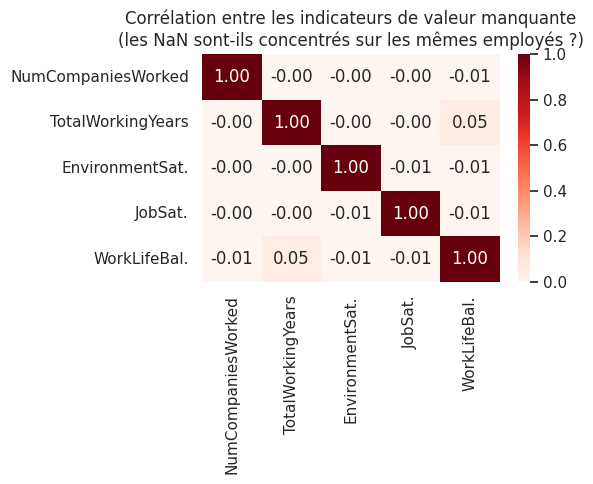


Nombre de colonnes manquantes par employé :
0    4300
1     109
2       1

→ 110 employés sur 4410 sont concernés par au moins une valeur manquante.


In [12]:
# Matrice de co-occurrence des valeurs manquantes
# Est-ce que les mêmes employés ont des NaN dans plusieurs colonnes ?
df_missing_flags = df[cols_with_missing].isnull().astype(int)
df_missing_flags.columns = [c.replace("Satisfaction", "Sat.").replace("Balance", "Bal.") for c in cols_with_missing]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_missing_flags.corr(), annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, ax=ax)
ax.set_title("Corrélation entre les indicateurs de valeur manquante\n(les NaN sont-ils concentrés sur les mêmes employés ?)")
plt.tight_layout()
plt.show()

# Nombre d'employés avec N colonnes manquantes
n_missing_per_row = df[cols_with_missing].isnull().sum(axis=1)
print("\nNombre de colonnes manquantes par employé :")
print(n_missing_per_row.value_counts().sort_index().to_string())
print(f"\n→ {(n_missing_per_row > 0).sum()} employés sur {len(df)} sont concernés par au moins une valeur manquante.")

### 1.5.3 Synthèse — Stratégie de nettoyage

| Colonne | Manquants | Type | Nature | Stratégie recommandée |
|---|---|---|---|---|
| `WorkLifeBalance` | 38 (0.9%) | Ordinale (1–4) | Enquête employé — non-réponse | **KNN Imputer** (k=5) + arrondi entier |
| `EnvironmentSatisfaction` | 25 (0.6%) | Ordinale (1–4) | Enquête employé — non-réponse | **KNN Imputer** (k=5) + arrondi entier |
| `JobSatisfaction` | 20 (0.5%) | Ordinale (1–4) | Enquête employé — non-réponse | **KNN Imputer** (k=5) + arrondi entier |
| `NumCompaniesWorked` | 19 (0.4%) | Numérique continue | Donnée RH manquante | **KNN Imputer** (k=5) |
| `TotalWorkingYears` | 9 (0.2%) | Numérique continue | Donnée RH manquante | **KNN Imputer** (k=5) |

**Pourquoi KNN Imputer ?**
- Algorithme **multivarié** : il exploite les corrélations entre toutes les variables numériques pour estimer les valeurs manquantes (contrairement à la médiane, qui est univariée).
- Les variables d'enquête sont potentiellement corrélées entre elles et avec des variables RH (ancienneté, salaire, département) : KNN permet d'en tirer parti.
- Le taux de NaN est très faible (< 1%) : KNN est performant et le coût computationnel reste raisonnable sur 4410 lignes.
- Pour les variables ordinales, on arrondit le résultat à l'entier le plus proche pour respecter l'échelle discrète.

**Colonnes à supprimer** : `EmployeeCount`, `Over18`, `StandardHours` (variance nulle), `EmployeeID` (identifiant).

## 1.6 Corrélation des variables numériques avec `Attrition`

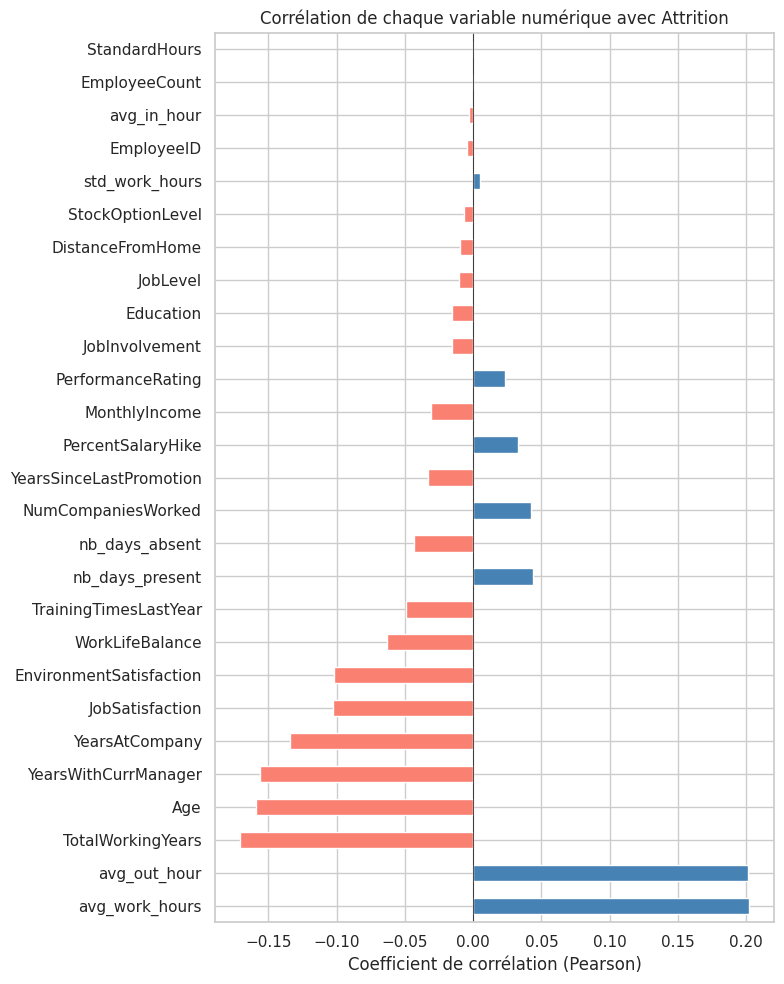

In [13]:
num_cols = df.select_dtypes(include="number").columns.tolist()
correlations = df[num_cols].corr()["Attrition_binary"].drop("Attrition_binary")
correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["salmon" if v < 0 else "steelblue" for v in correlations]
correlations.plot.barh(ax=ax, color=colors)
ax.set_title("Corrélation de chaque variable numérique avec Attrition")
ax.set_xlabel("Coefficient de corrélation (Pearson)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## 1.7 Résumé

Le DataFrame final `df` contient **4410 lignes** et combine :

| Source | Colonnes ajoutées | Type de jointure | Clé |
|---|---|---|---|
| `general_data.csv` | 24 cols (démographiques, salariales, carrière) | Table de base | `EmployeeID` |
| `employee_survey_data.csv` | 3 cols (satisfaction) | `LEFT JOIN` on `EmployeeID` | `EmployeeID` |
| `manager_survey_data.csv` | 2 cols (évaluation) | `LEFT JOIN` on `EmployeeID` | `EmployeeID` |
| `in_out_time/` (agrégé) | 6 cols (horaires) | `LEFT JOIN` on `EmployeeID` | index → `EmployeeID` |

Toutes les relations sont **1:1** (un enregistrement par employé dans chaque source).

In [14]:
print(f"DataFrame final : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes :\n{list(df.columns)}")

DataFrame final : 4410 lignes × 36 colonnes

Colonnes :
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_in_hour', 'avg_out_hour', 'avg_work_hours', 'std_work_hours', 'nb_days_present', 'nb_days_absent', 'Attrition_binary']


# 2. Prétraitement des données

> **Cadre éthique** — Cette étape met en œuvre plusieurs engagements pris dans notre cadre réglementaire :
> - **Principe 3 — Confidentialité et gouvernance des données** (HLEG) : minimisation des données (suppression des variables non nécessaires), pseudonymisation native via `EmployeeID`, contrôle de qualité (§2.4.3 du rapport)
> - **Principe 2 — Robustesse technique** (HLEG) : traitement rigoureux des valeurs manquantes, suppression des variables constantes, agrégation robuste du badgeage (§2.4.2)
> - **RGPD art. 5** : principe de minimisation — ne conserver que les données ayant un pouvoir prédictif démontré

On travaille sur une copie du DataFrame fusionné `df` pour ne pas altérer les données brutes.
Les étapes :
- **2.1** Suppression des colonnes inutiles et imputation des valeurs manquantes
- **2.2** Détection et traitement des outliers (méthode IQR)
- **2.3** Encodage des variables catégorielles et normalisation des variables numériques

In [15]:
df_clean = df.copy()
print(f"Copie de travail : {df_clean.shape}")
print(f"Valeurs manquantes avant traitement : {df_clean.isnull().sum().sum()}")

Copie de travail : (4410, 36)
Valeurs manquantes avant traitement : 111


## 2.1 Suppression des colonnes inutiles et imputation

### Suppression des colonnes à variance nulle et de l'identifiant

Comme identifié en §1.5.1, quatre colonnes ne portent aucune information prédictive.

In [16]:
cols_to_drop = ["EmployeeCount", "Over18", "StandardHours", "EmployeeID"]
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Colonnes supprimées : {cols_to_drop}")
print(f"Shape après suppression : {df_clean.shape}")

Colonnes supprimées : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']
Shape après suppression : (4410, 32)


### Imputation par KNN (K-Nearest Neighbors)

Plutôt qu'une imputation naïve par la médiane, on utilise l'algorithme **KNN Imputer** de scikit-learn, qui exploite la structure multivariée des données pour produire des estimations plus fidèles.

#### Principe

Pour chaque valeur manquante d'un employé $x_i$, l'algorithme :

1. **Identifie les $k$ voisins les plus proches** de $x_i$ parmi les employés dont la valeur est connue, en se basant sur les **autres colonnes** (celles sans NaN pour cette ligne).
2. **Calcule la distance euclidienne** entre $x_i$ et chaque voisin potentiel $x_j$ :

$$d(x_i, x_j) = \sqrt{\sum_{m \in \mathcal{F}} \left( x_i^{(m)} - x_j^{(m)} \right)^2}$$

   où $\mathcal{F}$ est l'ensemble des features **communes non-manquantes** entre $x_i$ et $x_j$.

3. **Impute la valeur manquante** par la **moyenne pondérée** (ou simple) des valeurs des $k$ voisins :

$$\hat{x}_i^{(\text{col})} = \frac{1}{k} \sum_{j \in \mathcal{N}_k(x_i)} x_j^{(\text{col})}$$

#### Pourquoi KNN plutôt que la médiane ?

| Critère | Médiane | KNN Imputer |
|---|---|---|
| Utilise les autres colonnes | Non (univarié) | **Oui** (multivarié) |
| Respecte les corrélations entre variables | Non | **Oui** |
| Adapté aux petits taux de NaN (< 1%) | Oui | **Oui** |
| Complexité | O(1) | O(n · p) |

Dans notre cas, les variables d'enquête (`WorkLifeBalance`, `JobSatisfaction`, `EnvironmentSatisfaction`) sont potentiellement corrélées entre elles et avec des variables RH (ancienneté, salaire, département). KNN permet d'en tirer parti.

On choisit **$k = 5$** (valeur standard, bon compromis biais/variance pour ~4400 lignes).

> **Note** : KNN Imputer nécessite que les features soient sur des **échelles comparables**. On effectue donc une normalisation temporaire avant imputation, puis on restaure l'échelle originale.

In [17]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler as _TempScaler

cols_to_impute = ["WorkLifeBalance", "EnvironmentSatisfaction", "JobSatisfaction",
                  "NumCompaniesWorked", "TotalWorkingYears"]

# Sélectionner toutes les colonnes numériques pour que KNN ait un contexte multivarié
num_cols_for_knn = df_clean.select_dtypes(include="number").columns.tolist()

print("Valeurs manquantes AVANT imputation KNN :\n")
for col in cols_to_impute:
    print(f"  {col:30s} : {df_clean[col].isnull().sum()} NaN")

# Étape 1 : normalisation temporaire (KNN est sensible à l'échelle)
temp_scaler = _TempScaler()
df_num_scaled = pd.DataFrame(
    temp_scaler.fit_transform(df_clean[num_cols_for_knn]),
    columns=num_cols_for_knn,
    index=df_clean.index
)

# Étape 2 : imputation KNN (k=5)
knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")
df_num_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_num_scaled),
    columns=num_cols_for_knn,
    index=df_clean.index
)

# Étape 3 : inverse de la normalisation pour revenir à l'échelle originale
df_num_original = pd.DataFrame(
    temp_scaler.inverse_transform(df_num_imputed),
    columns=num_cols_for_knn,
    index=df_clean.index
)

# Replacer les colonnes imputées dans df_clean
df_clean[num_cols_for_knn] = df_num_original

# Pour les variables ordinales (échelle entière 1-4), arrondir au plus proche entier
ordinal_imputed = ["WorkLifeBalance", "EnvironmentSatisfaction", "JobSatisfaction"]
for col in ordinal_imputed:
    df_clean[col] = df_clean[col].round().astype(int)

print("\nValeurs manquantes APRÈS imputation KNN :\n")
for col in cols_to_impute:
    print(f"  {col:30s} : {df_clean[col].isnull().sum()} NaN")

print(f"\nTotal NaN restants dans le DataFrame : {df_clean.isnull().sum().sum()}")

Valeurs manquantes AVANT imputation KNN :

  WorkLifeBalance                : 38 NaN
  EnvironmentSatisfaction        : 25 NaN
  JobSatisfaction                : 20 NaN
  NumCompaniesWorked             : 19 NaN
  TotalWorkingYears              : 9 NaN

Valeurs manquantes APRÈS imputation KNN :

  WorkLifeBalance                : 0 NaN
  EnvironmentSatisfaction        : 0 NaN
  JobSatisfaction                : 0 NaN
  NumCompaniesWorked             : 0 NaN
  TotalWorkingYears              : 0 NaN

Total NaN restants dans le DataFrame : 0


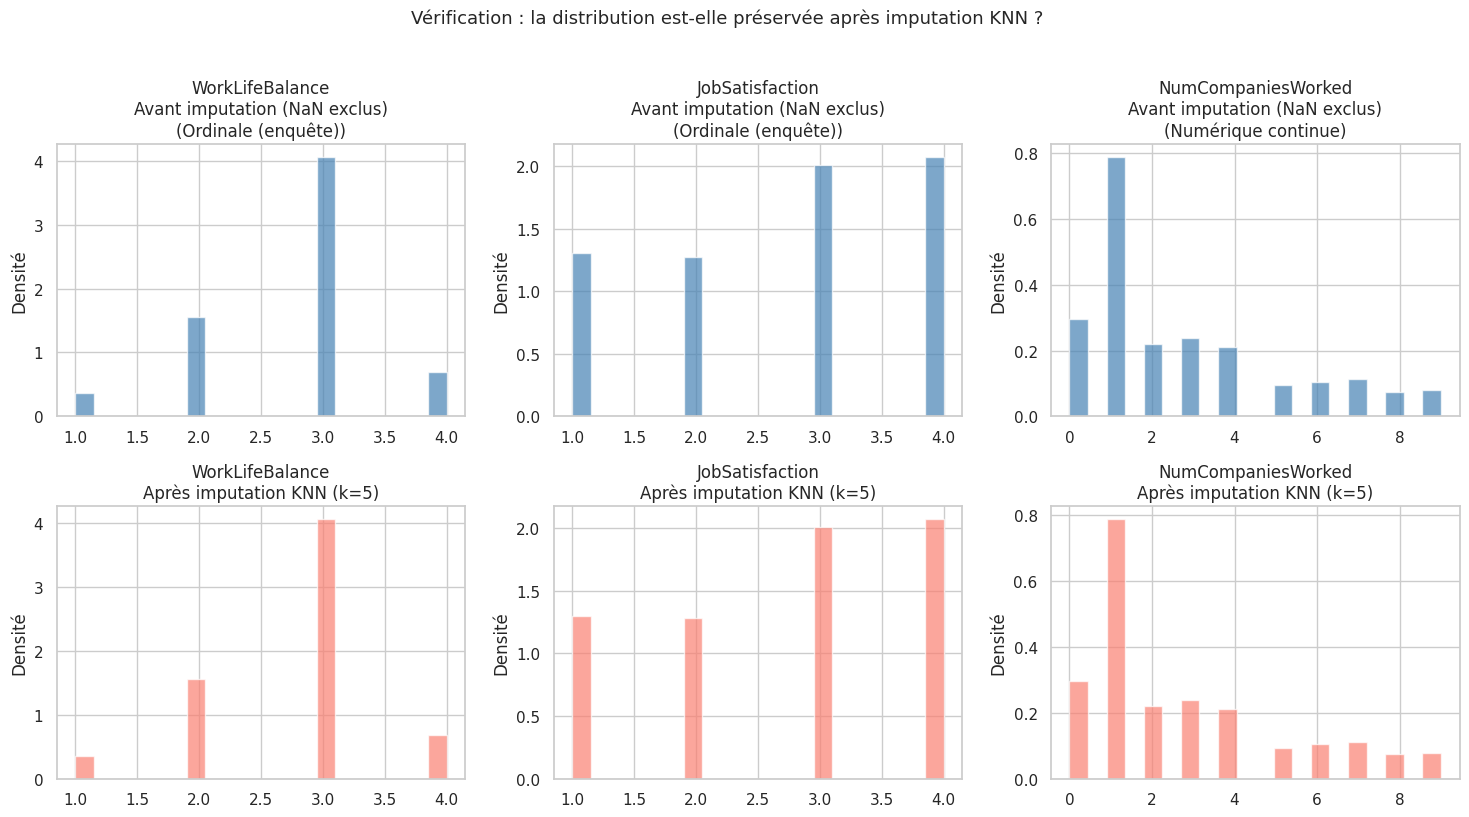

In [18]:
# Vérification visuelle : distribution avant/après imputation KNN
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

check_cols = ["WorkLifeBalance", "JobSatisfaction", "NumCompaniesWorked"]
titles = ["Ordinale (enquête)", "Ordinale (enquête)", "Numérique continue"]

for i, (col, title) in enumerate(zip(check_cols, titles)):
    # Avant : distribution du df original (sans NaN)
    df[col].dropna().plot.hist(ax=axes[0, i], bins=20, alpha=0.7, color="steelblue",
                                density=True, edgecolor="white")
    axes[0, i].set_title(f"{col}\nAvant imputation (NaN exclus)\n({title})")
    axes[0, i].set_ylabel("Densité")

    # Après : distribution post-KNN
    df_clean[col].plot.hist(ax=axes[1, i], bins=20, alpha=0.7, color="salmon",
                             density=True, edgecolor="white")
    axes[1, i].set_title(f"{col}\nAprès imputation KNN (k=5)")
    axes[1, i].set_ylabel("Densité")

plt.suptitle("Vérification : la distribution est-elle préservée après imputation KNN ?",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2.2 Détection et traitement des outliers

On utilise la **méthode IQR** (Interquartile Range) pour détecter les valeurs aberrantes dans les variables numériques continues.

Un point est considéré comme outlier si :
$$x < Q_1 - 1.5 \times IQR \quad \text{ou} \quad x > Q_3 + 1.5 \times IQR$$

On exclut de l'analyse :
- Les variables **ordinales** (échelles à choix limités : `Education`, `JobLevel`, `StockOptionLevel`, enquêtes 1–4, `PerformanceRating`)
- La variable cible `Attrition_binary`
- Les variables de badgeage agrégées `nb_days_present` / `nb_days_absent` (complémentaires, bornées par le nombre de jours ouvrés)

In [19]:
# Colonnes exclues de la détection d'outliers
ordinal_cols = ["Education", "JobLevel", "StockOptionLevel",
                "EnvironmentSatisfaction", "JobSatisfaction", "WorkLifeBalance",
                "JobInvolvement", "PerformanceRating"]
exclude_cols = ordinal_cols + ["Attrition_binary", "nb_days_present", "nb_days_absent"]

# Colonnes numériques continues à analyser
num_continuous = [c for c in df_clean.select_dtypes(include="number").columns
                  if c not in exclude_cols]

print(f"Colonnes numériques continues analysées ({len(num_continuous)}) :")
print(f"  {num_continuous}")

Colonnes numériques continues analysées (14) :
  ['Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'avg_in_hour', 'avg_out_hour', 'avg_work_hours', 'std_work_hours']


In [20]:
# Détection des outliers par la méthode IQR
print("=" * 85)
print("DÉTECTION DES OUTLIERS (méthode IQR, seuil = 1.5)")
print("=" * 85)

outlier_report = []

for col in num_continuous:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    n_out = mask.sum()
    pct = n_out / len(df_clean) * 100

    outlier_report.append({
        "colonne": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "borne_inf": lower, "borne_sup": upper,
        "nb_outliers": n_out, "pct": pct
    })

    if n_out > 0:
        print(f"\n  {col}")
        print(f"    Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  →  bornes [{lower:.1f}, {upper:.1f}]")
        print(f"    Outliers : {n_out} ({pct:.1f}%)")
        print(f"    Min={df_clean[col].min():.1f}  Max={df_clean[col].max():.1f}")

df_outliers = pd.DataFrame(outlier_report).sort_values("nb_outliers", ascending=False)
print(f"\n{'─' * 85}")
print(f"Total de colonnes avec outliers : {(df_outliers['nb_outliers'] > 0).sum()} / {len(num_continuous)}")

DÉTECTION DES OUTLIERS (méthode IQR, seuil = 1.5)

  MonthlyIncome
    Q1=29110.0  Q3=83800.0  IQR=54690.0  →  bornes [-52925.0, 165835.0]
    Outliers : 342 (7.8%)
    Min=10090.0  Max=199990.0

  NumCompaniesWorked
    Q1=1.0  Q3=4.0  IQR=3.0  →  bornes [-3.5, 8.5]
    Outliers : 156 (3.5%)
    Min=0.0  Max=9.0

  TotalWorkingYears
    Q1=6.0  Q3=15.0  IQR=9.0  →  bornes [-7.5, 28.5]
    Outliers : 189 (4.3%)
    Min=0.0  Max=40.0

  TrainingTimesLastYear
    Q1=2.0  Q3=3.0  IQR=1.0  →  bornes [0.5, 4.5]
    Outliers : 714 (16.2%)
    Min=0.0  Max=6.0

  YearsAtCompany
    Q1=3.0  Q3=9.0  IQR=6.0  →  bornes [-6.0, 18.0]
    Outliers : 312 (7.1%)
    Min=0.0  Max=40.0

  YearsSinceLastPromotion
    Q1=0.0  Q3=3.0  IQR=3.0  →  bornes [-4.5, 7.5]
    Outliers : 321 (7.3%)
    Min=0.0  Max=15.0

  YearsWithCurrManager
    Q1=2.0  Q3=7.0  IQR=5.0  →  bornes [-5.5, 14.5]
    Outliers : 42 (1.0%)
    Min=0.0  Max=17.0

  avg_in_hour
    Q1=10.0  Q3=10.0  IQR=0.0  →  bornes [9.9, 10.0]
    O

/tmp/ipykernel_29719/3908835789.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Attrition", y=col, ax=ax,
/tmp/ipykernel_29719/3908835789.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Attrition", y=col, ax=ax,
/tmp/ipykernel_29719/3908835789.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Attrition", y=col, ax=ax,
/tmp/ipykernel_29719/3908835789.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` v

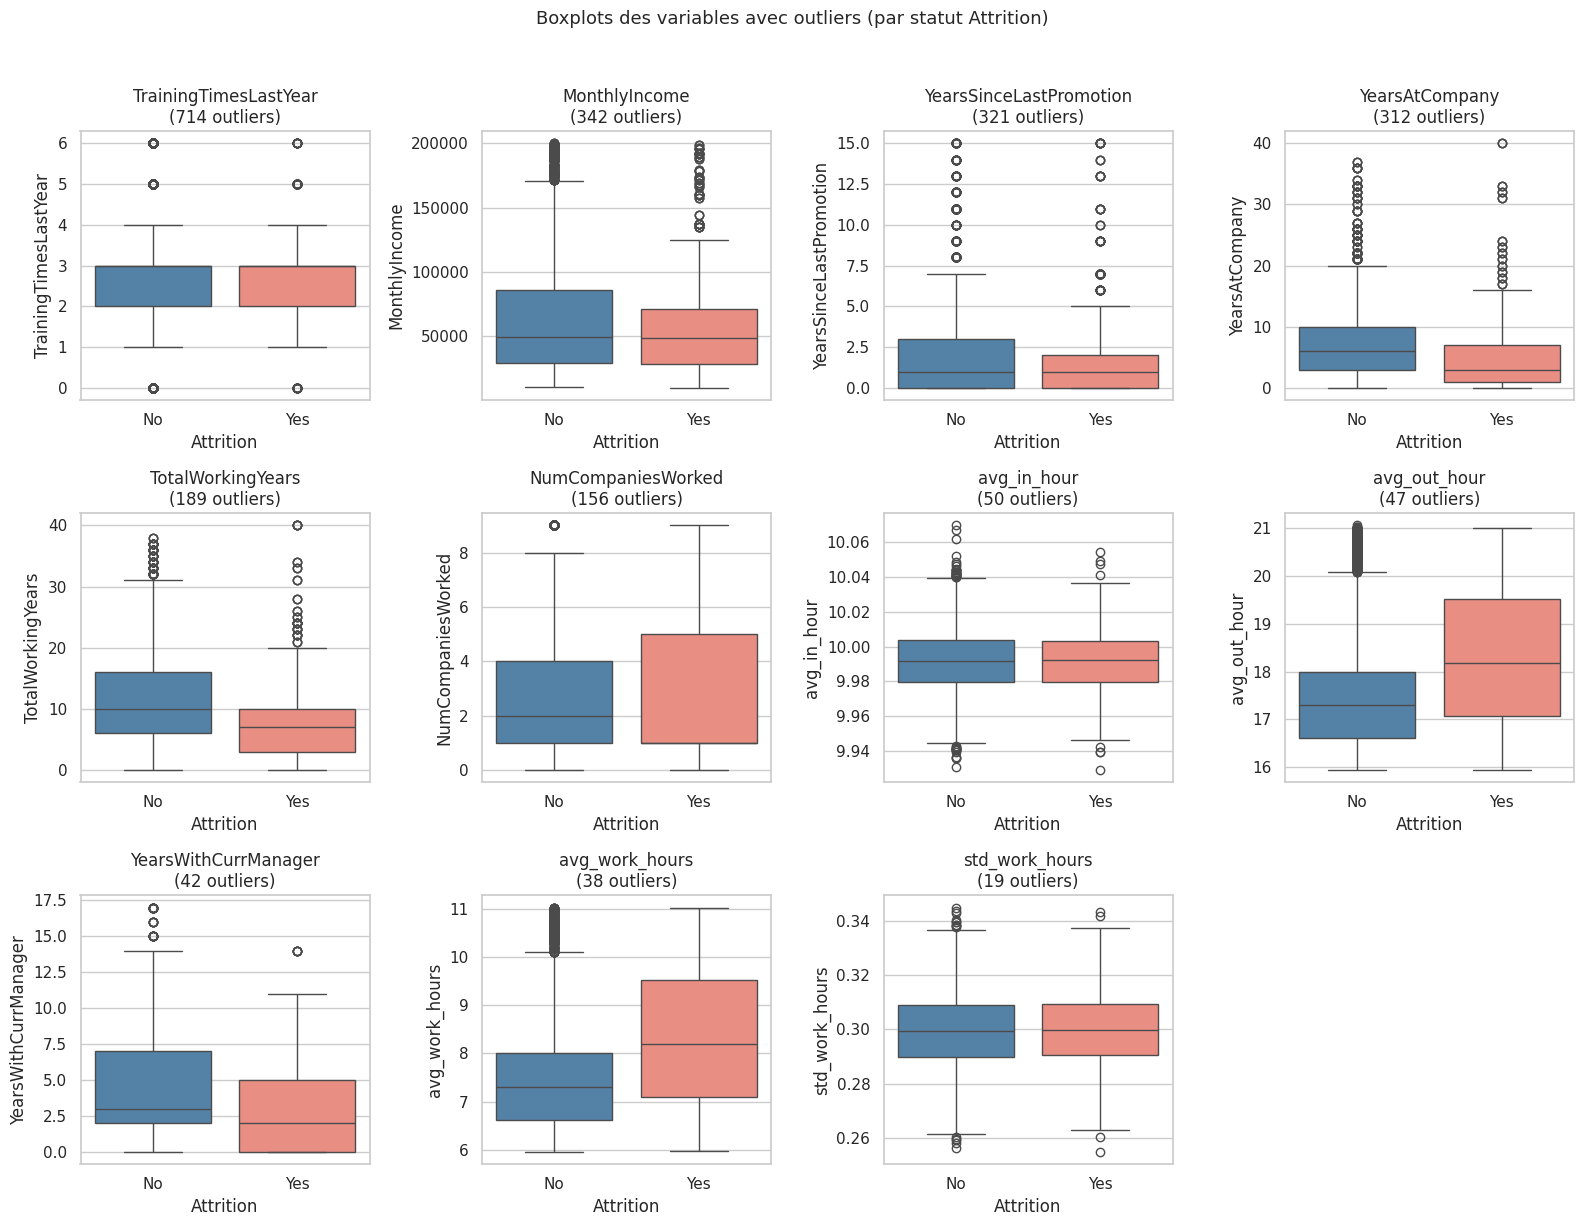

In [21]:
# Visualisation : boxplots des colonnes avec outliers
cols_with_outliers = df_outliers.loc[df_outliers["nb_outliers"] > 0, "colonne"].tolist()

if cols_with_outliers:
    n = len(cols_with_outliers)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).ravel() if n > 1 else [axes]

    for ax, col in zip(axes, cols_with_outliers):
        sns.boxplot(data=df_clean, x="Attrition", y=col, ax=ax,
                    palette={"No": "steelblue", "Yes": "salmon"})
        n_out = df_outliers.loc[df_outliers["colonne"] == col, "nb_outliers"].values[0]
        ax.set_title(f"{col}\n({n_out} outliers)")

    # Masquer les axes vides
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle("Boxplots des variables avec outliers (par statut Attrition)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Aucun outlier détecté.")

### Traitement des outliers par capping (winsorisation)

Plutôt que de supprimer les lignes contenant des outliers (ce qui réduirait le dataset et risquerait de biaiser la classe minoritaire `Attrition=Yes`), on applique un **capping** : les valeurs au-delà des bornes IQR sont ramenées à la borne la plus proche.

Cette approche :
- Préserve le nombre de lignes (important pour un dataset déséquilibré)
- Réduit l'influence des valeurs extrêmes sans les supprimer
- Est standard en amont de modèles sensibles aux outliers (régression logistique, KNN)

In [22]:
# Capping des outliers aux bornes IQR
print("Capping (winsorisation) des outliers :\n")

n_total_capped = 0
for col in cols_with_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_low = (df_clean[col] < lower).sum()
    n_high = (df_clean[col] > upper).sum()

    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    print(f"  {col:30s} : {n_low:3d} cappés en bas (→ {lower:.1f}), {n_high:3d} cappés en haut (→ {upper:.1f})")
    n_total_capped += n_low + n_high

print(f"\nTotal de valeurs cappées : {n_total_capped}")

Capping (winsorisation) des outliers :

  TrainingTimesLastYear          : 162 cappés en bas (→ 0.5), 552 cappés en haut (→ 4.5)
  MonthlyIncome                  :   0 cappés en bas (→ -52925.0), 342 cappés en haut (→ 165835.0)
  YearsSinceLastPromotion        :   0 cappés en bas (→ -4.5), 321 cappés en haut (→ 7.5)
  YearsAtCompany                 :   0 cappés en bas (→ -6.0), 312 cappés en haut (→ 18.0)
  TotalWorkingYears              :   0 cappés en bas (→ -7.5), 189 cappés en haut (→ 28.5)
  NumCompaniesWorked             :   0 cappés en bas (→ -3.5), 156 cappés en haut (→ 8.5)
  avg_in_hour                    :  19 cappés en bas (→ 9.9),  31 cappés en haut (→ 10.0)
  avg_out_hour                   :   0 cappés en bas (→ 14.1),  47 cappés en haut (→ 20.9)
  YearsWithCurrManager           :   0 cappés en bas (→ -5.5),  42 cappés en haut (→ 14.5)
  avg_work_hours                 :   0 cappés en bas (→ 4.1),  38 cappés en haut (→ 10.9)
  std_work_hours                 :   7 cappés en

In [23]:
# Vérification : plus aucun outlier IQR après capping
print("Vérification post-capping :\n")
for col in cols_with_outliers:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    status = "OK" if n_out == 0 else f"ATTENTION : {n_out} restants"
    print(f"  {col:30s} : {status}")

Vérification post-capping :

  TrainingTimesLastYear          : OK
  MonthlyIncome                  : OK
  YearsSinceLastPromotion        : OK
  YearsAtCompany                 : OK
  TotalWorkingYears              : OK
  NumCompaniesWorked             : OK
  avg_in_hour                    : OK
  avg_out_hour                   : OK
  YearsWithCurrManager           : OK
  avg_work_hours                 : OK
  std_work_hours                 : OK


## 2.3 Encodage des variables catégorielles et normalisation

### Encodage

Deux stratégies selon la nature de la variable :

| Type | Variables | Méthode |
|---|---|---|
| **Binaire** | `Attrition`, `Gender` | Label encoding (0/1) |
| **Nominale** (>2 catégories, pas d'ordre) | `BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus` | One-Hot Encoding (`pd.get_dummies`) |

Les variables ordinales (`Education`, `JobLevel`, `StockOptionLevel`, enquêtes 1–4, `PerformanceRating`) sont déjà codées numériquement et conservées telles quelles.

In [24]:
# 1. Encodage binaire
df_clean["Attrition"] = (df_clean["Attrition"] == "Yes").astype(int)
df_clean["Gender"] = (df_clean["Gender"] == "Male").astype(int)

# Supprimer Attrition_binary (doublon maintenant)
df_clean = df_clean.drop(columns=["Attrition_binary"], errors="ignore")

print("Encodage binaire :")
print(f"  Attrition : Yes→1, No→0  (distribution : {df_clean['Attrition'].value_counts().to_dict()})")
print(f"  Gender    : Male→1, Female→0  (distribution : {df_clean['Gender'].value_counts().to_dict()})")

Encodage binaire :
  Attrition : Yes→1, No→0  (distribution : {0: 3699, 1: 711})
  Gender    : Male→1, Female→0  (distribution : {1: 2646, 0: 1764})


In [25]:
# 2. One-Hot Encoding des variables nominales
nominal_cols = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"]

print(f"One-Hot Encoding de {len(nominal_cols)} colonnes nominales :")
for col in nominal_cols:
    print(f"  {col:20s} → {df_clean[col].nunique()} catégories : {df_clean[col].unique().tolist()}")

shape_before = df_clean.shape
df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True, dtype=int)

print(f"\nShape avant OHE : {shape_before}")
print(f"Shape après OHE : {df_clean.shape}")
print(f"Nouvelles colonnes ajoutées : {df_clean.shape[1] - shape_before[1] + len(nominal_cols)}")

One-Hot Encoding de 5 colonnes nominales :
  BusinessTravel       → 3 catégories : ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
  Department           → 3 catégories : ['Sales', 'Research & Development', 'Human Resources']
  EducationField       → 6 catégories : ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
  JobRole              → 9 catégories : ['Healthcare Representative', 'Research Scientist', 'Sales Executive', 'Human Resources', 'Research Director', 'Laboratory Technician', 'Manufacturing Director', 'Sales Representative', 'Manager']
  MaritalStatus        → 3 catégories : ['Married', 'Single', 'Divorced']

Shape avant OHE : (4410, 31)
Shape après OHE : (4410, 45)
Nouvelles colonnes ajoutées : 19


In [26]:
df_clean.head()

,Age,Attrition,DistanceFromHome,Education,Gender,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,avg_in_hour,avg_out_hour,avg_work_hours,std_work_hours,nb_days_present,nb_days_absent,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,51.0,0,6.0,2.0,0,1.0,131160.0,1.0,11.0,0.0,1.0,4.5,1.0,0.0,0.0,3,4,2,3.0,3.0,9.993032,17.367170,7.373651,0.283224,232.0,29.0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,31.0,1,10.0,1.0,0,1.0,41890.0,0.0,23.0,1.0,6.0,3.0,5.0,1.0,4.0,3,2,4,2.0,4.0,9.980720,17.698446,7.718969,0.313351,236.0,25.0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,32.0,0,17.0,4.0,1,4.0,165835.0,1.0,15.0,3.0,5.0,2.0,5.0,0.0,3.0,2,2,1,3.0,3.0,10.016598,17.030096,7.013240,0.311551,242.0,19.0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0
3,38.0,0,2.0,5.0,1,3.0,83210.0,3.0,11.0,3.0,13.0,4.5,8.0,7.0,5.0,4,4,3,2.0,3.0,9.973830,17.167305,7.193678,0.284133,235.0,26.0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0
4,32.0,0,10.0,1.0,1,1.0,23420.0,4.0,12.0,2.0,9.0,2.0,6.0,0.0,4.0,4,1,3,3.0,3.0,9.990068,17.996327,8.006175,0.300656,245.0,16.0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1


### Feature Engineering — Remplacement des variables colinéaires par des ratios métier

L'analyse de corrélation révèle plusieurs groupes de variables fortement colinéaires :

| Groupe | Variables corrélées | Corrélation |
|---|---|---|
| **Ancienneté** | `YearsAtCompany` ↔ `YearsWithCurrManager` | 0.77 |
| | `YearsAtCompany` ↔ `YearsSinceLastPromotion` | 0.62 |
| **Expérience** | `Age` ↔ `TotalWorkingYears` | 0.68 |
| **Badgeage** | `avg_out_hour` ↔ `avg_work_hours` | 1.00 (redondance parfaite) |
| | `nb_days_present` ↔ `nb_days_absent` | -1.00 (complémentaires) |

**Stratégie** : Plutôt que de supprimer ces colonnes et perdre de l'information, on les **croise pour créer des ratios métier** interprétables par les RH. Ces ratios capturent la *relation* entre les variables (ex : proportion de carrière dans l'entreprise) plutôt que leurs valeurs brutes, ce qui casse la colinéarité tout en enrichissant le signal.

In [27]:
# === Feature Engineering : croisement des variables colinéaires ===

print("Création de features croisées à partir des variables colinéaires :\n")

# --- Groupe 1 : Ancienneté (YearsAtCompany, YearsWithCurrManager, YearsSinceLastPromotion) ---

# Stabilité managériale : proportion du temps passé avec le même manager
# Un ratio faible peut indiquer des changements fréquents de manager → instabilité
df_clean["ManagerStability"] = df_clean["YearsWithCurrManager"] / (df_clean["YearsAtCompany"] + 1)
print("  ManagerStability    = YearsWithCurrManager / (YearsAtCompany + 1)")

# Stagnation de carrière : proportion du temps depuis la dernière promotion
# Un ratio élevé signifie que l'employé attend une promotion depuis longtemps → frustration
df_clean["PromotionStagnation"] = df_clean["YearsSinceLastPromotion"] / (df_clean["YearsAtCompany"] + 1)
print("  PromotionStagnation = YearsSinceLastPromotion / (YearsAtCompany + 1)")

# --- Groupe 2 : Expérience (Age, TotalWorkingYears) ---

# Fidélité à l'entreprise : proportion de la carrière passée ici
# Un ratio élevé = employé fidèle, faible = parcours diversifié
df_clean["CompanyLoyalty"] = df_clean["YearsAtCompany"] / (df_clean["TotalWorkingYears"] + 1)
print("  CompanyLoyalty      = YearsAtCompany / (TotalWorkingYears + 1)")

# Maturité professionnelle : proportion de la vie passée à travailler
# Capture la relation Age/TotalWorkingYears sans colinéarité
df_clean["CareerMaturity"] = df_clean["TotalWorkingYears"] / (df_clean["Age"] + 1)
print("  CareerMaturity      = TotalWorkingYears / (Age + 1)")

# Mobilité professionnelle : fréquence de changement d'entreprise
# Un taux élevé = profil « job hopper », facteur de risque connu en RH
df_clean["JobHoppingRate"] = df_clean["NumCompaniesWorked"] / (df_clean["TotalWorkingYears"] + 1)
print("  JobHoppingRate      = NumCompaniesWorked / (TotalWorkingYears + 1)")

# --- Groupe 3 : Badgeage (redondances parfaites) ---

# avg_out_hour est parfaitement corrélé avec avg_work_hours (r=1.0) → supprimer
df_clean = df_clean.drop(columns=["avg_out_hour"], errors="ignore")
print("\n  Suppression de avg_out_hour (r=1.0 avec avg_work_hours)")

# nb_days_absent est le complément exact de nb_days_present → supprimer
df_clean = df_clean.drop(columns=["nb_days_absent"], errors="ignore")
print("  Suppression de nb_days_absent (r=-1.0 avec nb_days_present)")

# --- Suppression des variables originales remplacées par les ratios ---
cols_replaced = ["YearsWithCurrManager", "YearsSinceLastPromotion",
                 "TotalWorkingYears", "Age", "NumCompaniesWorked"]
df_clean = df_clean.drop(columns=cols_replaced, errors="ignore")
print(f"\n  Suppression des colonnes originales remplacées : {cols_replaced}")

print(f"\nNouvelles features créées : 5")
print(f"Colonnes supprimées      : 7 (5 remplacées + 2 redondantes)")
print(f"Gain net                 : -2 colonnes")
print(f"\nShape après feature engineering : {df_clean.shape}")

Création de features croisées à partir des variables colinéaires :

  ManagerStability    = YearsWithCurrManager / (YearsAtCompany + 1)
  PromotionStagnation = YearsSinceLastPromotion / (YearsAtCompany + 1)
  CompanyLoyalty      = YearsAtCompany / (TotalWorkingYears + 1)
  CareerMaturity      = TotalWorkingYears / (Age + 1)
  JobHoppingRate      = NumCompaniesWorked / (TotalWorkingYears + 1)

  Suppression de avg_out_hour (r=1.0 avec avg_work_hours)
  Suppression de nb_days_absent (r=-1.0 avec nb_days_present)

  Suppression des colonnes originales remplacées : ['YearsWithCurrManager', 'YearsSinceLastPromotion', 'TotalWorkingYears', 'Age', 'NumCompaniesWorked']

Nouvelles features créées : 5
Colonnes supprimées      : 7 (5 remplacées + 2 redondantes)
Gain net                 : -2 colonnes

Shape après feature engineering : (4410, 43)


### Normalisation (StandardScaler)

On applique une **standardisation** (centrage-réduction) aux variables numériques continues pour que chaque feature ait une moyenne de 0 et un écart-type de 1.

On **exclut** de la normalisation :
- La variable cible `Attrition`
- Les colonnes binaires issues du one-hot encoding (déjà en 0/1)
- Les variables ordinales (échelle discrète à interpréter)

In [28]:
from sklearn.preprocessing import StandardScaler

# Identifier les colonnes binaires (0/1 uniquement)
binary_cols = [c for c in df_clean.columns
               if set(df_clean[c].unique()).issubset({0, 1})]

# Colonnes à ne PAS normaliser
no_scale = set(binary_cols + ordinal_cols + ["Attrition"])

# Colonnes à normaliser
cols_to_scale = [c for c in df_clean.select_dtypes(include="number").columns
                 if c not in no_scale]

print(f"Colonnes à normaliser ({len(cols_to_scale)}) :")
print(f"  {cols_to_scale}")
print(f"\nColonnes NON normalisées ({len(no_scale)}) :")
print(f"  binaires ({len(binary_cols)}), ordinales ({len([c for c in ordinal_cols if c in df_clean.columns])}), cible (1)")

Colonnes à normaliser (14) :
  ['DistanceFromHome', 'MonthlyIncome', 'PercentSalaryHike', 'TrainingTimesLastYear', 'YearsAtCompany', 'avg_in_hour', 'avg_work_hours', 'std_work_hours', 'nb_days_present', 'ManagerStability', 'PromotionStagnation', 'CompanyLoyalty', 'CareerMaturity', 'JobHoppingRate']

Colonnes NON normalisées (29) :
  binaires (21), ordinales (8), cible (1)


In [29]:
scaler = StandardScaler()
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

# Vérification
print("Après standardisation (extrait) :\n")
print(df_clean[cols_to_scale].describe().round(2).to_string())

Après standardisation (extrait) :

       DistanceFromHome  MonthlyIncome  PercentSalaryHike  TrainingTimesLastYear  YearsAtCompany  avg_in_hour  avg_work_hours  std_work_hours  nb_days_present  ManagerStability  PromotionStagnation  CompanyLoyalty  CareerMaturity  JobHoppingRate
count           4410.00        4410.00            4410.00                4410.00         4410.00      4410.00         4410.00         4410.00          4410.00           4410.00              4410.00         4410.00         4410.00         4410.00
mean               0.00          -0.00               0.00                  -0.00            0.00         0.00           -0.00            0.00             0.00              0.00                 0.00           -0.00            0.00            0.00
std                1.00           1.00               1.00                   1.00            1.00         1.00            1.00            1.00             1.00              1.00                 1.00            1.00            1.

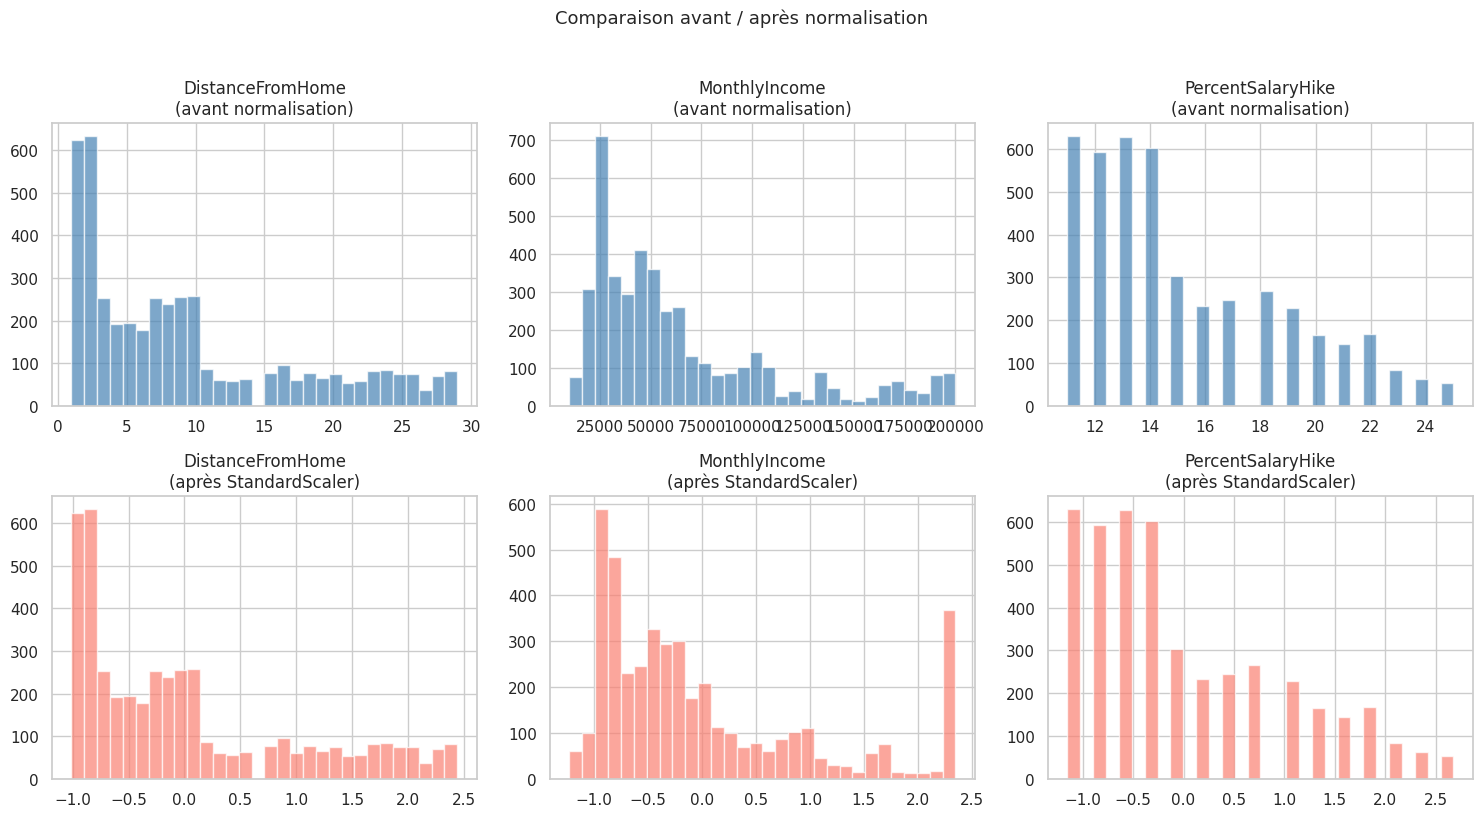

In [30]:
# Visualisation avant/après normalisation pour quelques variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sample_cols = cols_to_scale[:3]

for i, col in enumerate(sample_cols):
    # Avant (données cappées, non normalisées)
    vals_before = df[col].dropna() if col in df.columns else df_clean[col]
    axes[0, i].hist(vals_before, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
    axes[0, i].set_title(f"{col}\n(avant normalisation)")

    # Après
    axes[1, i].hist(df_clean[col], bins=30, color="salmon", alpha=0.7, edgecolor="white")
    axes[1, i].set_title(f"{col}\n(après StandardScaler)")

plt.suptitle("Comparaison avant / après normalisation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2.4 Résumé du prétraitement

| Étape | Action | Détail |
|---|---|---|
| **Suppression** | 4 colonnes retirées | `EmployeeCount`, `Over18`, `StandardHours` (variance nulle), `EmployeeID` (identifiant) |
| **Imputation** | KNN Imputer (k=5) sur 5 colonnes | Normalisation temporaire → imputation multivariée → inverse scaling. Arrondi entier pour les ordinales |
| **Outliers** | Capping IQR (winsorisation) | Variables numériques continues ramenées aux bornes $[Q_1 - 1.5 \cdot IQR,\; Q_3 + 1.5 \cdot IQR]$ |
| **Encodage binaire** | 2 colonnes | `Attrition` (Yes→1), `Gender` (Male→1) |
| **One-Hot Encoding** | 5 colonnes nominales | `BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus` (`drop_first=True`) |
| **Normalisation** | StandardScaler | Variables numériques continues centrées-réduites (moyenne=0, écart-type=1) |

Le DataFrame `df_clean` est maintenant prêt pour la modélisation.

In [31]:
print(f"DataFrame final prétraité : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")
print(f"Valeurs manquantes       : {df_clean.isnull().sum().sum()}")
print(f"Variable cible           : Attrition → {df_clean['Attrition'].value_counts().to_dict()}")
print(f"\nTypes de colonnes :")
print(df_clean.dtypes.value_counts().to_string())
print(f"\nListe des colonnes :\n{list(df_clean.columns)}")

DataFrame final prétraité : 4410 lignes × 43 colonnes
Valeurs manquantes       : 0
Variable cible           : Attrition → {0: 3699, 1: 711}

Types de colonnes :
int64      24
float64    19

Liste des colonnes :
['Attrition', 'DistanceFromHome', 'Education', 'Gender', 'JobLevel', 'MonthlyIncome', 'PercentSalaryHike', 'StockOptionLevel', 'TrainingTimesLastYear', 'YearsAtCompany', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'avg_in_hour', 'avg_work_hours', 'std_work_hours', 'nb_days_present', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'Jo

# 3. Modèle 1 : Régression Logistique

> **Cadre éthique** — La régression logistique est le modèle le plus **transparent** (principe 4 — Transparence, HLEG) : ses coefficients fournissent une explication directe de l'influence de chaque variable sur la prédiction. Cela satisfait l'exigence d'explicabilité de l'AI Act et la recommandation de la CNIL de « rendre les systèmes algorithmiques compréhensibles ».
>
> Le `class_weight="balanced"` implémente le **principe 5 — Diversité, non-discrimination et équité** en empêchant le modèle d'ignorer la classe minoritaire (les départs).

## Théorie

La régression logistique modélise la **probabilité** qu'un employé quitte l'entreprise en appliquant la fonction sigmoïde à une combinaison linéaire des features :

$$P(\text{Attrition} = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

Le modèle est entraîné en minimisant la **log-vraisemblance négative** (binary cross-entropy) :

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

**Avantages** : interprétable (chaque coefficient mesure l'impact d'une feature), rapide, bon baseline.
**Limites** : suppose une frontière de décision linéaire, sensible à la multicolinéarité.

### Pourquoi une analyse de multicolinéarité ?

Quand deux features sont très corrélées, les coefficients deviennent instables et difficiles à interpréter. On utilise le **VIF** (Variance Inflation Factor) pour détecter ce problème :

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

où $R_j^2$ est le $R^2$ de la régression de la feature $j$ sur toutes les autres. Un VIF > 5 indique une multicolinéarité problématique.

## 3.1 Préparation commune : séparation train/test

### Qu'est-ce que le Grid Search ?

Le **Grid Search** (recherche par grille) est une méthode systématique d'**optimisation des hyperparamètres** d'un modèle de machine learning.

**Principe** : On définit une grille de combinaisons d'hyperparamètres à tester. Pour chaque combinaison, le modèle est entraîné et évalué par **validation croisée stratifiée** (5 folds). La combinaison qui produit le meilleur score est retenue.

**Pourquoi ?** Les hyperparamètres (ex : profondeur d'un arbre, taux d'apprentissage, architecture d'un réseau) ne s'apprennent pas à partir des données — ils doivent être fixés *avant* l'entraînement. Un mauvais choix peut mener à du **sous-apprentissage** (modèle trop simple) ou du **sur-apprentissage** (modèle trop complexe).

**Métrique d'optimisation** : Nous utilisons le **F1-score** comme critère principal car notre jeu de données est déséquilibré (16% d'attrition). Le F1 est la moyenne harmonique de la précision et du rappel, ce qui pénalise les modèles qui sacrifient l'un au profit de l'autre.

**Processus pour chaque modèle** :
1. Définir la grille d'hyperparamètres à explorer
2. Lancer `GridSearchCV` avec validation croisée stratifiée (5 folds)
3. Sélectionner la meilleure combinaison selon le F1-score
4. Ré-entraîner le modèle final avec ces hyperparamètres optimaux
5. Évaluer sur le jeu de test (identique pour les 3 modèles)

In [32]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, f1_score, precision_score, recall_score, accuracy_score)

# Séparation features / cible
X = df_clean.drop(columns=["Attrition"])
y = df_clean["Attrition"]

# Split stratifié 80/20 (préserve le ratio 16/84)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} lignes ({y_train.mean()*100:.1f}% attrition)")
print(f"Test  : {X_test.shape[0]} lignes ({y_test.mean()*100:.1f}% attrition)")
print(f"Features : {X_train.shape[1]}")

Train : 3528 lignes (16.1% attrition)
Test  : 882 lignes (16.1% attrition)
Features : 42


## 3.2 Analyse de multicolinéarité (VIF)

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculer le VIF pour chaque feature numérique
# On exclut les colonnes binaires (OHE) car le VIF n'a pas de sens pour elles
binary_feature_cols = [c for c in X_train.columns if set(X_train[c].unique()).issubset({0, 1})]
non_binary_cols = [c for c in X_train.columns if c not in binary_feature_cols]

vif_data = pd.DataFrame({
    "Feature": non_binary_cols,
    "VIF": [variance_inflation_factor(X_train[non_binary_cols].values, i)
            for i in range(len(non_binary_cols))]
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factor (VIF) — colonnes non-binaires :\n")
for _, row in vif_data.iterrows():
    flag = " ⚠️  MULTICOLINÉARITÉ" if row["VIF"] > 5 else ""
    print(f"  {row['Feature']:30s} : VIF = {row['VIF']:8.2f}{flag}")

print(f"\nColonnes avec VIF > 5 : {(vif_data['VIF'] > 5).sum()} / {len(vif_data)}")

Variance Inflation Factor (VIF) — colonnes non-binaires :

  PerformanceRating              : VIF =    47.00 ⚠️  MULTICOLINÉARITÉ
  WorkLifeBalance                : VIF =    15.70 ⚠️  MULTICOLINÉARITÉ
  JobInvolvement                 : VIF =    15.22 ⚠️  MULTICOLINÉARITÉ
  Education                      : VIF =     8.86 ⚠️  MULTICOLINÉARITÉ
  EnvironmentSatisfaction        : VIF =     7.18 ⚠️  MULTICOLINÉARITÉ
  JobSatisfaction                : VIF =     6.94 ⚠️  MULTICOLINÉARITÉ
  YearsAtCompany                 : VIF =     6.32 ⚠️  MULTICOLINÉARITÉ
  CompanyLoyalty                 : VIF =     4.57
  CareerMaturity                 : VIF =     4.52
  JobLevel                       : VIF =     4.48
  StockOptionLevel               : VIF =     1.88
  JobHoppingRate                 : VIF =     1.53
  ManagerStability               : VIF =     1.42
  PercentSalaryHike              : VIF =     1.41
  PromotionStagnation            : VIF =     1.11
  avg_work_hours                 : VIF =    

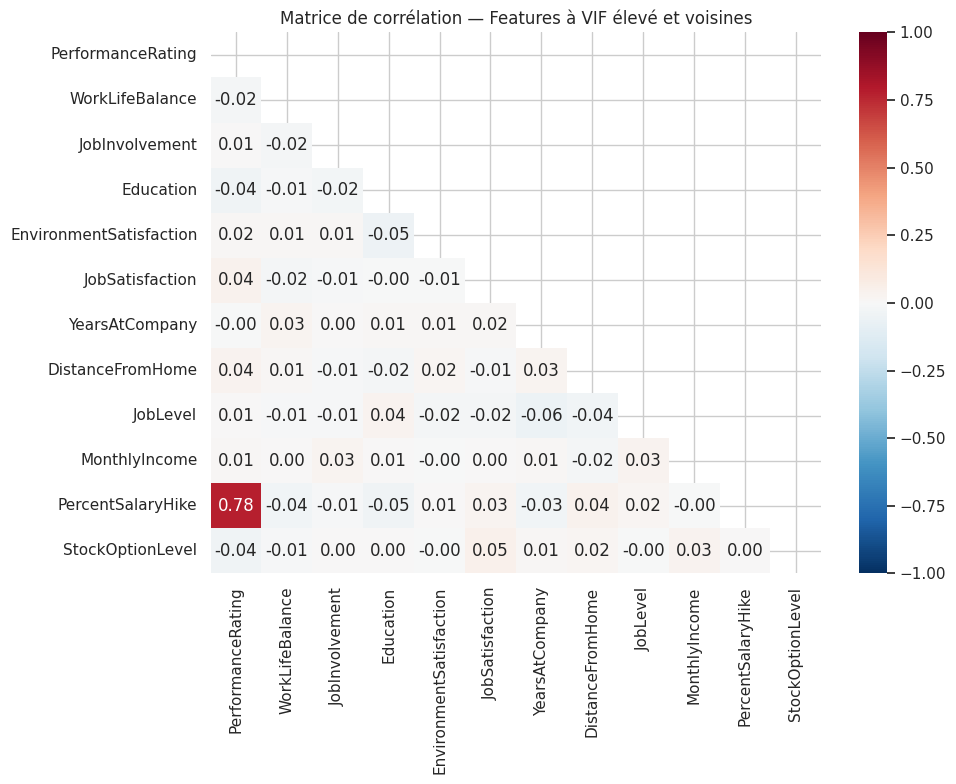


→ Les features fortement corrélées entre elles partagent de l'information redondante.
  Pour la régression logistique, on peut envisager d'en supprimer certaines.


In [34]:
# Visualisation : matrice de corrélation des features à VIF élevé
high_vif_cols = vif_data.loc[vif_data["VIF"] > 5, "Feature"].tolist()

if high_vif_cols:
    # Ajouter les colonnes les plus corrélées avec celles à VIF élevé
    cols_to_show = high_vif_cols + [c for c in non_binary_cols if c not in high_vif_cols][:5]
    fig, ax = plt.subplots(figsize=(10, 8))
    corr_matrix = X_train[cols_to_show].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title("Matrice de corrélation — Features à VIF élevé et voisines")
    plt.tight_layout()
    plt.show()
    
    print("\n→ Les features fortement corrélées entre elles partagent de l'information redondante.")
    print("  Pour la régression logistique, on peut envisager d'en supprimer certaines.")
else:
    print("Aucune feature avec VIF > 5 — pas de multicolinéarité problématique.")

## 3.3 Vérification post-feature engineering — VIF résiduel

In [35]:
# Vérification : le feature engineering a-t-il résolu la multicolinéarité ?
print("VIF après feature engineering :\n")

selected_cols = non_binary_cols.copy()
vifs_post = pd.Series(
    [variance_inflation_factor(X_train[selected_cols].values, i)
     for i in range(len(selected_cols))],
    index=selected_cols
).sort_values(ascending=False)

for col, vif in vifs_post.items():
    flag = " ⚠️  VIF > 5" if vif > 5 else " ✓"
    print(f"  {col:30s} : VIF = {vif:8.2f}{flag}")

# S'il reste des VIF > 5, on les supprime itérativement
remaining_high = vifs_post[vifs_post > 5].index.tolist()
if remaining_high:
    print(f"\n⚠️  {len(remaining_high)} feature(s) avec VIF > 5 — suppression itérative :")
    while True:
        vifs = pd.Series(
            [variance_inflation_factor(X_train[selected_cols].values, i)
             for i in range(len(selected_cols))],
            index=selected_cols
        )
        max_vif = vifs.max()
        if max_vif <= 5:
            break
        drop_col = vifs.idxmax()
        print(f"  Suppression de {drop_col:30s} (VIF = {max_vif:.2f})")
        selected_cols.remove(drop_col)
else:
    print("\n✅ Toutes les features ont un VIF ≤ 5 — pas de multicolinéarité résiduelle.")

# Colonnes finales pour la régression logistique
lr_features = selected_cols + binary_feature_cols
print(f"\nFeatures retenues (non-binaires) : {len(selected_cols)} / {len(non_binary_cols)}")
print(f"Features binaires conservées     : {len(binary_feature_cols)}")
print(f"Total features pour LogReg       : {len(lr_features)}")

VIF après feature engineering :

  PerformanceRating              : VIF =    47.00 ⚠️  VIF > 5
  WorkLifeBalance                : VIF =    15.70 ⚠️  VIF > 5
  JobInvolvement                 : VIF =    15.22 ⚠️  VIF > 5
  Education                      : VIF =     8.86 ⚠️  VIF > 5
  EnvironmentSatisfaction        : VIF =     7.18 ⚠️  VIF > 5
  JobSatisfaction                : VIF =     6.94 ⚠️  VIF > 5
  YearsAtCompany                 : VIF =     6.32 ⚠️  VIF > 5
  CompanyLoyalty                 : VIF =     4.57 ✓
  CareerMaturity                 : VIF =     4.52 ✓
  JobLevel                       : VIF =     4.48 ✓
  StockOptionLevel               : VIF =     1.88 ✓
  JobHoppingRate                 : VIF =     1.53 ✓
  ManagerStability               : VIF =     1.42 ✓
  PercentSalaryHike              : VIF =     1.41 ✓
  PromotionStagnation            : VIF =     1.11 ✓
  avg_work_hours                 : VIF =     1.09 ✓
  nb_days_present                : VIF =     1.08 ✓
  TrainingTim

## 3.4 Grid Search et entraînement de la régression logistique

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres pour la régression logistique
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"],
    "class_weight": ["balanced"],
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True
)

lr_grid.fit(X_train[lr_features], y_train)

print(f"\nMeilleurs hyperparamètres LR :\n{lr_grid.best_params_}")
print(f"Meilleur F1 (CV) : {lr_grid.best_score_:.4f}")

# Utiliser le meilleur modèle
lr_model = lr_grid.best_estimator_

y_pred_lr = lr_model.predict(X_test[lr_features])
y_proba_lr = lr_model.predict_proba(X_test[lr_features])[:, 1]

print(f"\n=== Régression Logistique — Résultats sur le test set (meilleure config) ===\n")
print(classification_report(y_test, y_pred_lr, target_names=["No", "Yes"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_lr):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/aniss/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/aniss/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/aniss/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid thi


Meilleurs hyperparamètres LR :
{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Meilleur F1 (CV) : 0.4655

=== Régression Logistique — Résultats sur le test set (meilleure config) ===

              precision    recall  f1-score   support

          No       0.93      0.78      0.84       740
         Yes       0.37      0.68      0.48       142

    accuracy                           0.76       882
   macro avg       0.65      0.73      0.66       882
weighted avg       0.84      0.76      0.79       882

AUC-ROC : 0.7939


/home/aniss/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/aniss/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


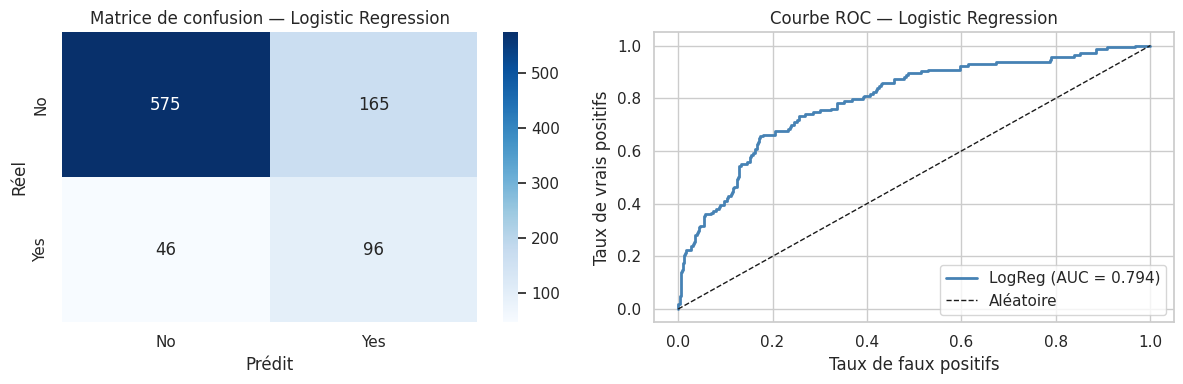

In [37]:
# Matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title("Matrice de confusion — Logistic Regression")

# Courbe ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
axes[1].plot(fpr_lr, tpr_lr, color="steelblue", lw=2,
             label=f"LogReg (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC — Logistic Regression")
axes[1].legend()

plt.tight_layout()
plt.show()

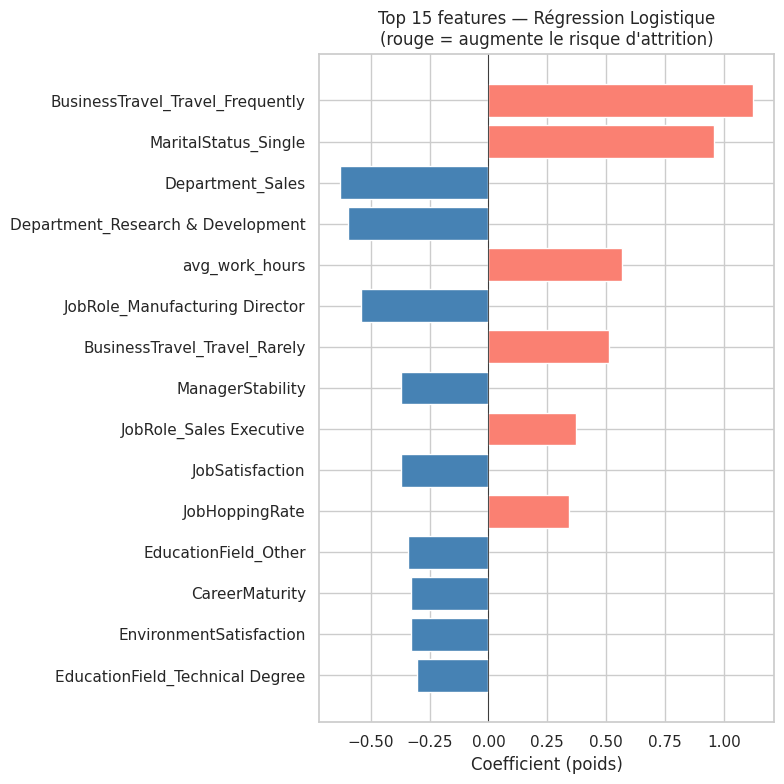

In [38]:
# Top 15 coefficients les plus importants (en valeur absolue)
coef_df = pd.DataFrame({
    "Feature": lr_features,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
top_n = 15
top_coefs = coef_df.head(top_n)
colors = ["salmon" if c > 0 else "steelblue" for c in top_coefs["Coefficient"]]
ax.barh(range(top_n), top_coefs["Coefficient"].values, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_coefs["Feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Coefficient (poids)")
ax.set_title("Top 15 features — Régression Logistique\n(rouge = augmente le risque d'attrition)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

# 4. Modèle 2 : Random Forest

> **Cadre éthique** — Le Random Forest offre un bon compromis entre performance et interprétabilité partielle :
> - **Principe 4 — Transparence** : la feature importance native permet d'identifier les facteurs structurels d'attrition (§2.4.4). L'explicabilité sera complétée par SHAP en partie 7.
> - **Principe 2 — Robustesse** : l'ensemble d'arbres réduit la variance et le surapprentissage. La validation croisée stratifiée (§2.4.2) garantit une estimation fiable.
> - **Principe 5 — Équité** : `class_weight="balanced"` et l'audit d'équité post-entraînement (partie 8) conformément à §2.4.5.

## Théorie

Le **Random Forest** est un ensemble de $B$ arbres de décision entraînés indépendamment, chacun sur un échantillon bootstrap du dataset. La prédiction finale est obtenue par **vote majoritaire** :

$$\hat{y} = \text{mode}\left\{ h_b(\mathbf{x}) \right\}_{b=1}^{B}$$

Chaque arbre $h_b$ est construit en ne considérant qu'un **sous-ensemble aléatoire de $m$ features** à chaque nœud (typiquement $m = \sqrt{p}$ où $p$ est le nombre total de features). Cette double randomisation (bagging + feature subsampling) réduit la **variance** et combat le **surapprentissage**.

**Avantages** :
- Pas d'hypothèse de linéarité, capture les interactions complexes
- Robuste aux outliers et au bruit
- Feature importance native (Mean Decrease in Impurity)
- `class_weight="balanced"` pour gérer le déséquilibre

**Limites** :
- Moins interprétable qu'une régression logistique (boîte grise)
- Peut être lent sur de très grands datasets

## 4.1 Grid Search et entraînement du Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres pour le Random Forest
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf": [2, 4, 8],
    "class_weight": ["balanced"],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True
)

rf_grid.fit(X_train, y_train)

print(f"\nMeilleurs hyperparamètres RF :\n{rf_grid.best_params_}")
print(f"Meilleur F1 (CV) : {rf_grid.best_score_:.4f}")

# Utiliser le meilleur modèle
rf_model = rf_grid.best_estimator_

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"\n=== Random Forest — Résultats sur le test set (meilleure config) ===\n")
print(classification_report(y_test, y_pred_rf, target_names=["No", "Yes"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs hyperparamètres RF :
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Meilleur F1 (CV) : 0.8616

=== Random Forest — Résultats sur le test set (meilleure config) ===

              precision    recall  f1-score   support

          No       0.98      1.00      0.99       740
         Yes       1.00      0.88      0.94       142

    accuracy                           0.98       882
   macro avg       0.99      0.94      0.96       882
weighted avg       0.98      0.98      0.98       882

AUC-ROC : 0.9886


## 4.2 Évaluation du Random Forest

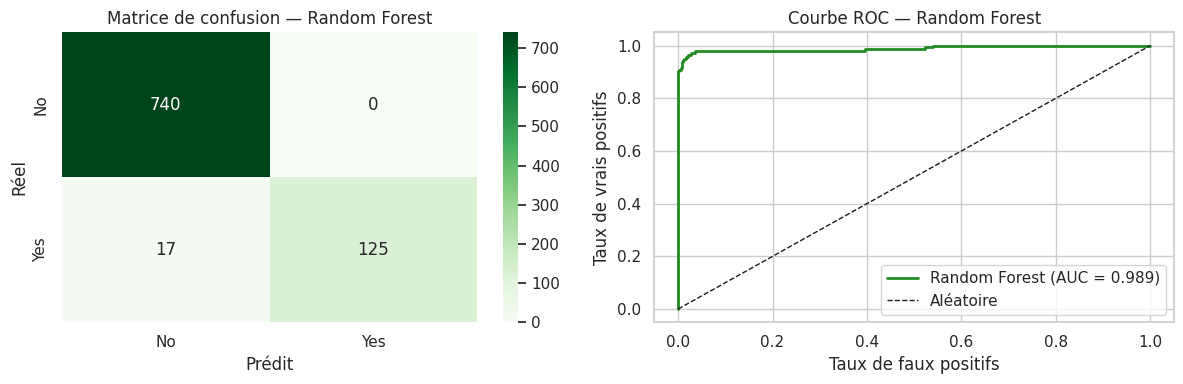

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title("Matrice de confusion — Random Forest")

# Courbe ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, color="forestgreen", lw=2,
             label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC — Random Forest")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.3 Feature Importance

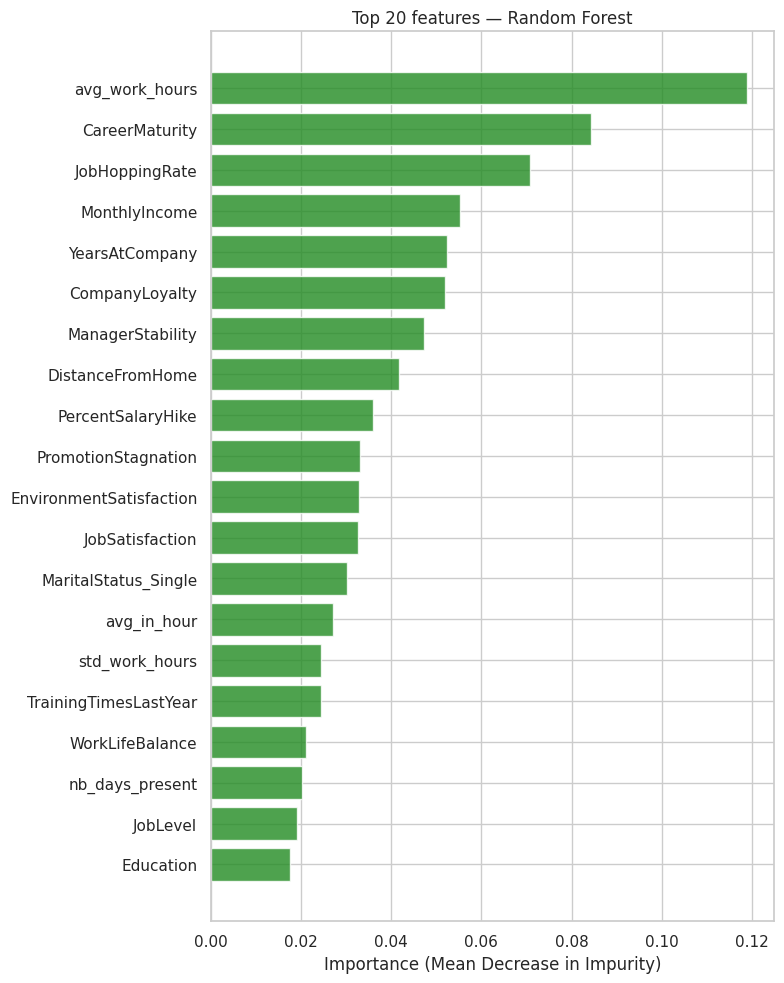


Top 10 features les plus importantes :
  avg_work_hours                      : 0.1189
  CareerMaturity                      : 0.0844
  JobHoppingRate                      : 0.0707
  MonthlyIncome                       : 0.0552
  YearsAtCompany                      : 0.0524
  CompanyLoyalty                      : 0.0519
  ManagerStability                    : 0.0472
  DistanceFromHome                    : 0.0417
  PercentSalaryHike                   : 0.0360
  PromotionStagnation                 : 0.0330


In [41]:
# Feature importance (Mean Decrease in Impurity)
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
top_n = 20
top_imp = importances.head(top_n)
ax.barh(range(top_n), top_imp["Importance"].values, color="forestgreen", alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_imp["Feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
ax.set_title(f"Top {top_n} features — Random Forest")
plt.tight_layout()
plt.show()

print("\nTop 10 features les plus importantes :")
for _, row in importances.head(10).iterrows():
    print(f"  {row['Feature']:35s} : {row['Importance']:.4f}")

# 5. Modèle 3 : MLP (Perceptron Multi-Couches)

> **Cadre éthique** — Le MLP est un modèle de type **boîte noire**, ce qui pose un défi direct pour le **principe 4 — Transparence** du HLEG et les exigences de l'AI Act :
> - L'explicabilité ne peut pas venir du modèle lui-même → **SHAP** (partie 7) est obligatoire pour satisfaire les exigences de transparence
> - C'est précisément ce type de modèle que le programme **XAI de la DARPA** (2017-2021) cherchait à rendre explicable, aboutissant aux outils SHAP et LIME que nous utilisons
> - **Principe 1 — Supervision humaine** (§2.4.1) : le MLP produit une probabilité, mais la décision reste humaine. Le `early_stopping` implémente la robustesse technique (principe 2).

## Théorie

Le **MLP** (Multi-Layer Perceptron) est un réseau de neurones artificiels composé de couches successives de neurones connectés. Chaque neurone calcule :

$$z = \mathbf{w}^T \mathbf{x} + b \quad ; \quad a = \phi(z)$$

où $\phi$ est une **fonction d'activation** non-linéaire (typiquement ReLU : $\phi(z) = \max(0, z)$).

Pour un réseau à $L$ couches, la sortie est la composition :

$$\hat{y} = \sigma\left( \mathbf{W}^{(L)} \cdot \phi\left( \mathbf{W}^{(L-1)} \cdots \phi\left( \mathbf{W}^{(1)} \mathbf{x} + \mathbf{b}^{(1)} \right) \cdots + \mathbf{b}^{(L-1)} \right) + \mathbf{b}^{(L)} \right)$$

L'entraînement se fait par **rétropropagation du gradient** (backpropagation) en minimisant la cross-entropy avec l'optimiseur **Adam** :

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \hat{m}_t \,/\, (\sqrt{\hat{v}_t} + \epsilon)$$

où $\hat{m}_t$ et $\hat{v}_t$ sont les estimations adaptatives des premier et second moments du gradient.

**Avantages** :
- Approximateur universel — peut modéliser n'importe quelle fonction continue
- Capture des interactions non-linéaires complexes entre features
- Flexible (architecture ajustable)

**Limites** :
- Boîte noire — difficile à interpréter directement
- Sensible à l'initialisation et aux hyperparamètres
- Nécessite des données normalisées (déjà fait en §2.3)

## 5.1 Gestion du déséquilibre de classes

In [42]:
# Le MLPClassifier de sklearn n'a pas de paramètre class_weight.
# On calcule des poids de classes manuellement pour les passer via sample_weight
# ou on utilise SMOTE pour rééquilibrer le jeu d'entraînement.

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight("balanced", y_train)

print(f"Distribution y_train : {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"\nPoids attribués :")
print(f"  Classe 0 (No)  : {sample_weights[y_train == 0][0]:.4f}")
print(f"  Classe 1 (Yes) : {sample_weights[y_train == 1][0]:.4f}")
print(f"  → La classe minoritaire reçoit un poids ~{sample_weights[y_train == 1][0] / sample_weights[y_train == 0][0]:.1f}x plus élevé")

Distribution y_train : {0: np.int64(2959), 1: np.int64(569)}

Poids attribués :
  Classe 0 (No)  : 0.5961
  Classe 1 (Yes) : 3.1002
  → La classe minoritaire reçoit un poids ~5.2x plus élevé


## 5.2 Grid Search et entraînement du MLP

In [43]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres pour le MLP
mlp_param_grid = {
    "hidden_layer_sizes": [(64, 32), (64, 32, 16), (128, 64, 32)],
    "learning_rate_init": [0.001, 0.01],
    "alpha": [0.0001, 0.001, 0.01],
    "activation": ["relu", "tanh"],
}

mlp_base = MLPClassifier(
    solver="adam",
    learning_rate="adaptive",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

mlp_grid = GridSearchCV(
    mlp_base,
    mlp_param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Fit avec sample_weight pour gérer le déséquilibre
mlp_grid.fit(X_train, y_train, sample_weight=sample_weights)

print(f"\nMeilleurs hyperparamètres MLP :\n{mlp_grid.best_params_}")
print(f"Meilleur F1 (CV) : {mlp_grid.best_score_:.4f}")

# Le meilleur modèle est automatiquement ré-entraîné (refit=True)
mlp_model = mlp_grid.best_estimator_

y_pred_mlp = mlp_model.predict(X_test)
y_proba_mlp = mlp_model.predict_proba(X_test)[:, 1]

print(f"\n=== MLP — Résultats sur le test set (meilleure config) ===\n")
print(f"Architecture : {mlp_model.hidden_layer_sizes}")
print(f"Itérations   : {mlp_model.n_iter_} / {mlp_model.max_iter}")
print(f"Loss finale  : {mlp_model.loss_:.4f}\n")
print(classification_report(y_test, y_pred_mlp, target_names=["No", "Yes"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_mlp):.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Meilleurs hyperparamètres MLP :
{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32, 16), 'learning_rate_init': 0.01}
Meilleur F1 (CV) : 0.8968

=== MLP — Résultats sur le test set (meilleure config) ===

Architecture : (64, 32, 16)
Itérations   : 55 / 500
Loss finale  : 0.0019

              precision    recall  f1-score   support

          No       0.98      0.99      0.98       740
         Yes       0.95      0.87      0.91       142

    accuracy                           0.97       882
   macro avg       0.96      0.93      0.95       882
weighted avg       0.97      0.97      0.97       882

AUC-ROC : 0.9611


## 5.3 Évaluation du MLP

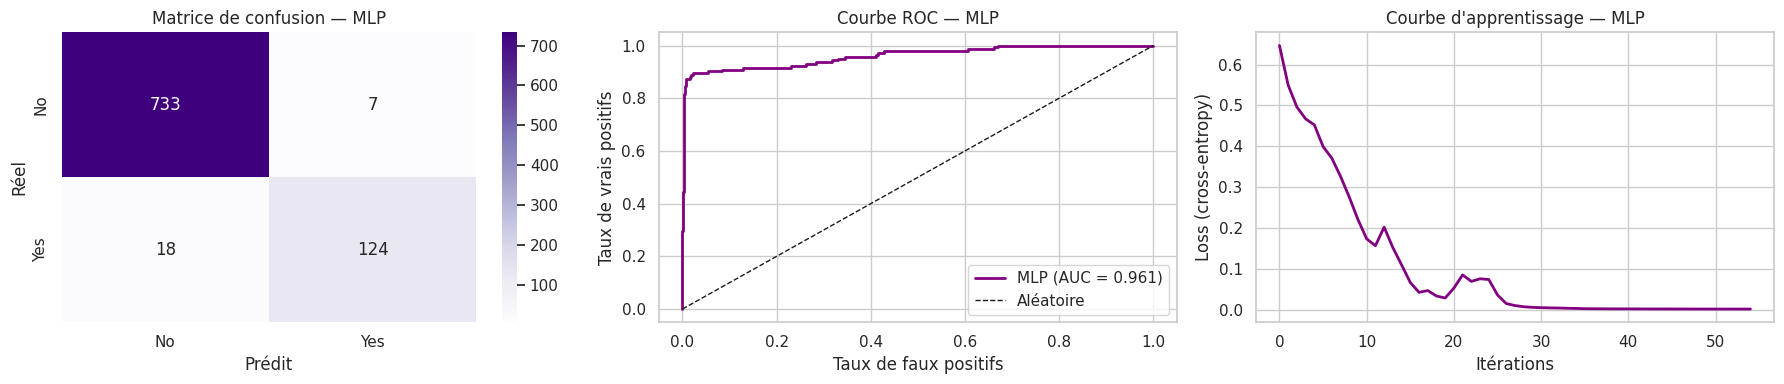

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Purples", ax=axes[0],
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title("Matrice de confusion — MLP")

# Courbe ROC
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
axes[1].plot(fpr_mlp, tpr_mlp, color="purple", lw=2,
             label=f"MLP (AUC = {roc_auc_score(y_test, y_proba_mlp):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Aléatoire")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC — MLP")
axes[1].legend()

# Courbe de loss
axes[2].plot(mlp_model.loss_curve_, color="purple", lw=2)
axes[2].set_xlabel("Itérations")
axes[2].set_ylabel("Loss (cross-entropy)")
axes[2].set_title("Courbe d'apprentissage — MLP")

plt.tight_layout()
plt.show()

# 6. Comparaison des modèles

Nous comparons les 3 modèles sur le **même jeu de test** et via **validation croisée stratifiée** (5 folds) pour évaluer la stabilité des performances.

Métriques retenues :
- **Accuracy** — taux de bonnes prédictions global
- **Precision (Yes)** — parmi les employés prédits "Yes", combien le sont vraiment ?
- **Recall (Yes)** — parmi les vrais "Yes", combien ont été détectés ? (**métrique clé** : on veut minimiser les employés à risque non détectés)
- **F1-score (Yes)** — moyenne harmonique precision/recall
- **AUC-ROC** — capacité globale à discriminer les classes

## 6.1 Tableau comparatif sur le jeu de test

In [45]:
# Rassembler les résultats
models = {
    "Logistic Regression": (y_pred_lr, y_proba_lr),
    "Random Forest": (y_pred_rf, y_proba_rf),
    "MLP": (y_pred_mlp, y_proba_mlp),
}

results = []
for name, (y_pred, y_proba) in models.items():
    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Yes)": precision_score(y_test, y_pred),
        "Recall (Yes)": recall_score(y_test, y_pred),
        "F1 (Yes)": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
    })

df_results = pd.DataFrame(results).set_index("Modèle")
print("=== Comparaison des modèles sur le test set ===\n")
print(df_results.round(4).to_string())

=== Comparaison des modèles sur le test set ===

                     Accuracy  Precision (Yes)  Recall (Yes)  F1 (Yes)  AUC-ROC
Modèle                                                                         
Logistic Regression    0.7608           0.3678        0.6761    0.4764   0.7939
Random Forest          0.9807           1.0000        0.8803    0.9363   0.9886
MLP                    0.9717           0.9466        0.8732    0.9084   0.9611


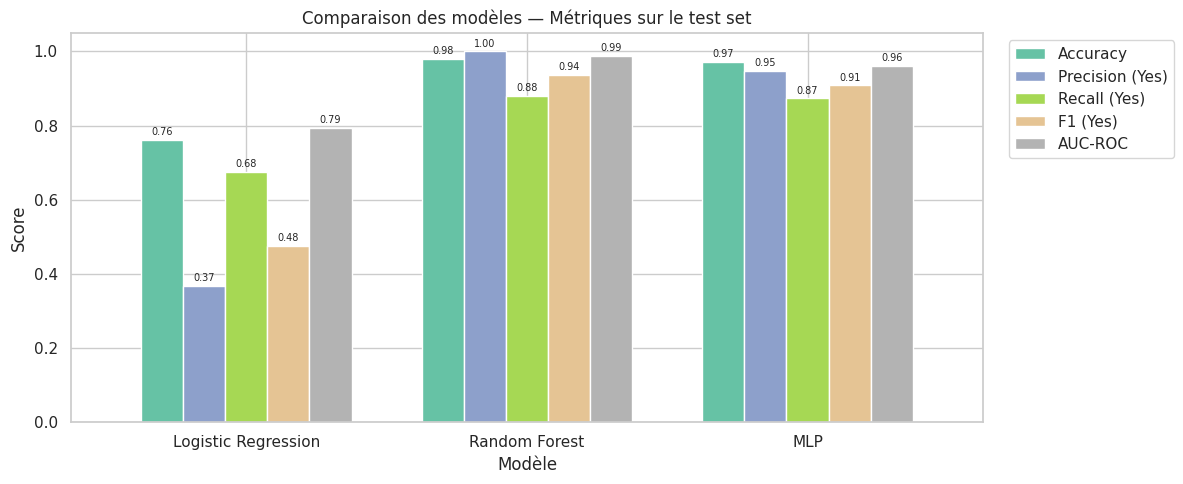

In [46]:
# Visualisation : barplot des métriques
fig, ax = plt.subplots(figsize=(12, 5))
df_results.plot.bar(ax=ax, rot=0, colormap="Set2", edgecolor="white", width=0.75)
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles — Métriques sur le test set")
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

# Ajouter les valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()

## 6.2 Validation croisée stratifiée (5 folds)

In [47]:
# Validation croisée sur le jeu d'entraînement complet
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_split=10,
                                             min_samples_leaf=4, class_weight="balanced",
                                             random_state=42, n_jobs=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32, 16), activation="relu", solver="adam",
                          learning_rate="adaptive", max_iter=500, early_stopping=True,
                          validation_fraction=0.15, n_iter_no_change=20, random_state=42),
}

# Note : pour le MLP, cross_validate ne passe pas sample_weight automatiquement,
# mais les résultats restent informatifs pour comparer la stabilité

cv_results = {}
for name, model in cv_models.items():
    # Pour la LogReg, utiliser les features sélectionnées
    X_cv = X[lr_features] if name == "Logistic Regression" else X
    scores = cross_validate(model, X_cv, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "Accuracy": f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        "Precision": f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        "Recall": f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "F1": f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "AUC-ROC": f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
    }

df_cv = pd.DataFrame(cv_results).T
print("=== Validation croisée stratifiée (5 folds) ===\n")
print(df_cv.to_string())

=== Validation croisée stratifiée (5 folds) ===

                            Accuracy        Precision           Recall               F1          AUC-ROC
Logistic Regression  0.7370 ± 0.0192  0.3464 ± 0.0208  0.7047 ± 0.0237  0.4641 ± 0.0202  0.7965 ± 0.0218
Random Forest        0.9621 ± 0.0029  0.9330 ± 0.0257  0.8256 ± 0.0260  0.8754 ± 0.0104  0.9863 ± 0.0033
MLP                  0.9433 ± 0.0129  0.8584 ± 0.0365  0.7765 ± 0.0638  0.8144 ± 0.0475  0.9572 ± 0.0246


## 6.3 Courbes ROC comparées

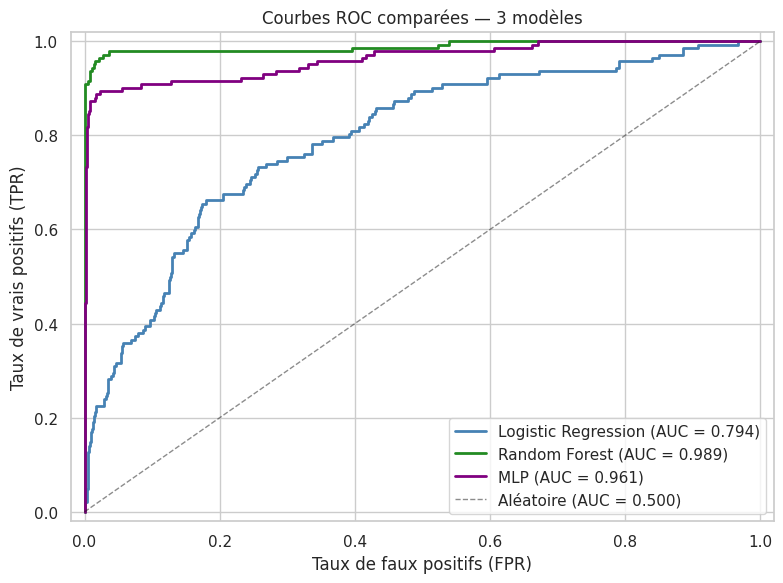

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
ax.plot(fpr_lr, tpr_lr, color="steelblue", lw=2,
        label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")

# Random Forest
ax.plot(fpr_rf, tpr_rf, color="forestgreen", lw=2,
        label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")

# MLP
ax.plot(fpr_mlp, tpr_mlp, color="purple", lw=2,
        label=f"MLP (AUC = {roc_auc_score(y_test, y_proba_mlp):.3f})")

# Aléatoire
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Aléatoire (AUC = 0.500)")

ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR)")
ax.set_title("Courbes ROC comparées — 3 modèles")
ax.legend(loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

## 6.4 Matrices de confusion comparées

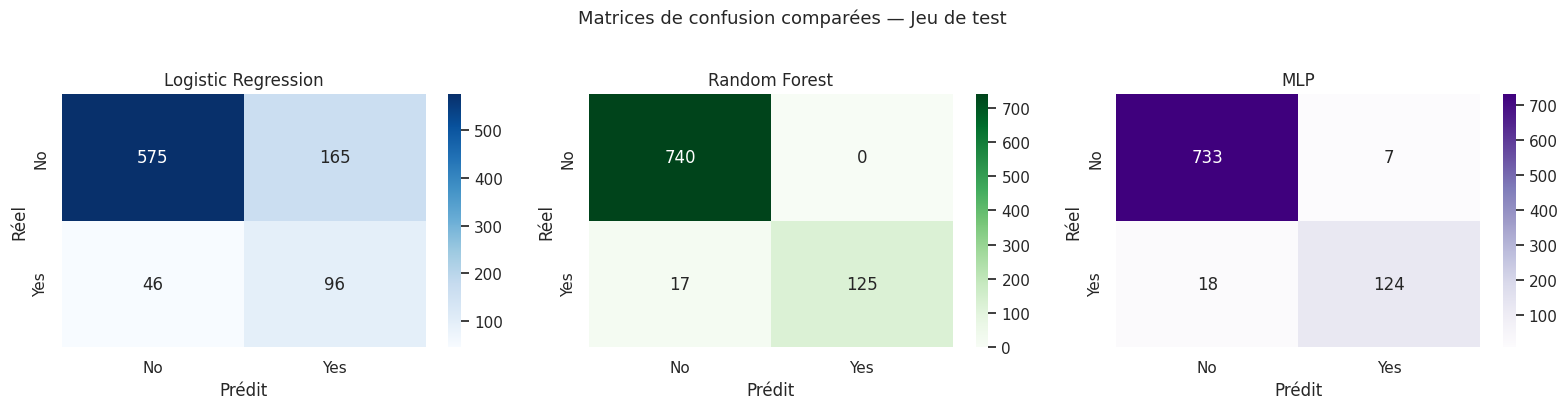

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (y_pred, _)), cmap in zip(
    axes,
    models.items(),
    ["Blues", "Greens", "Purples"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.set_title(name)

plt.suptitle("Matrices de confusion comparées — Jeu de test", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6.5 Synthèse et recommandation

### Critères de choix

Pour un projet RH de prédiction d'attrition, le **recall** sur la classe "Yes" est la métrique la plus importante : il vaut mieux identifier un employé à risque qui ne partira pas (faux positif → simple entretien de suivi) que de rater un employé qui va partir (faux négatif → départ non anticipé).

Ce choix de métrique est un **choix éthique explicite** conforme au principe d'*ethics by design* (§2.4 du rapport) : on privilégie le recall pour « ne pas invisibiliser les départs » (CNIL, principe de loyauté).

### Interprétabilité et conformité réglementaire

| Modèle | Interprétabilité | Conformité AI Act / RGPD | Principe HLEG |
|---|---|---|---|
| Régression Logistique | Élevée (coefficients directs) | Oui — explicable nativement | Principe 4 — Transparence |
| Random Forest | Moyenne (feature importance + SHAP) | Oui — avec explicabilité post-hoc | Principes 2 & 4 — Robustesse & Transparence |
| MLP | Faible (boîte noire) | Nécessite SHAP/LIME obligatoirement | Principe 4 — exige XAI (cf. DARPA) |

### Rappel — Supervision humaine (Principe 1, RGPD art. 22)

> **Le modèle retenu est un outil d'aide à la décision, pas un système de décision automatique.** Conformément à nos engagements (§2.4.1), toute prédiction d'attrition doit être examinée par un responsable RH qualifié avant qu'une action ne soit envisagée. Le modèle produit un score de risque et des facteurs explicatifs (SHAP) ; c'est le responsable RH qui décide de la suite.

Le modèle retenu devra être accompagné d'une **couche d'explicabilité SHAP** (partie 7) et d'un **audit d'équité** (partie 8) pour satisfaire l'ensemble des exigences.

# 7. Explicabilité — SHAP (SHapley Additive exPlanations)

> **Cadre éthique — Principe 4 : Transparence** (HLEG, §2.4.4 du rapport)
>
> *« Les systèmes d'IA sont développés de manière à permettre une traçabilité et une explicabilité appropriées »* — AI Act, considérant 27
>
> *« Rendre les systèmes algorithmiques compréhensibles »* — CNIL, 2017
>
> Le programme **XAI de la DARPA** (2017-2021) a démontré que la transparence des modèles n'est pas seulement éthique mais une nécessité pratique. SHAP, issu de ces travaux, est aujourd'hui la référence pour l'explicabilité post-hoc.

## Théorie

SHAP repose sur la théorie des **valeurs de Shapley** issue de la théorie des jeux coopératifs (Lloyd Shapley, 1953). Pour une prédiction donnée, la valeur SHAP de la feature $j$ mesure sa **contribution marginale** à la prédiction :

$$\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|! \cdot (|F| - |S| - 1)!}{|F|!} \left[ f(S \cup \{j\}) - f(S) \right]$$

où $F$ est l'ensemble de toutes les features et $f(S)$ la prédiction du modèle n'utilisant que le sous-ensemble $S$.

**Propriétés clés** :
- **Additivité** : $f(\mathbf{x}) = \phi_0 + \sum_{j=1}^{p} \phi_j$ — la prédiction est la somme exacte des contributions
- **Consistance** : si une feature contribue plus dans un modèle, sa valeur SHAP est plus élevée
- **Symétrie** : deux features ayant la même contribution reçoivent la même valeur SHAP

### Pourquoi SHAP ?

Conformément à notre engagement de **transparence** (§2.4.4), SHAP permet :
1. **Explicabilité individuelle** : pour chaque employé à risque, un *waterfall plot* montre quels facteurs poussent vers le départ (ex: heures de travail excessives, faible satisfaction)
2. **Explicabilité globale** : un *summary plot* révèle les leviers structurels d'attrition à l'échelle de l'entreprise
3. **Droit de contestation** (§2.4.7, Principe 7 — Responsabilité) : en cas de contestation par un employé, le rapport SHAP individuel permet de justifier la prédiction

In [50]:
import shap

# On utilise le Random Forest pour SHAP (TreeExplainer = exact et rapide)
explainer = shap.TreeExplainer(rf_model)
shap_values_raw = explainer.shap_values(X_test)

# Selon la version de SHAP, le format diffère :
# - Ancien : liste [shap_class0, shap_class1], chaque élément shape (n, p)
# - Nouveau : array shape (n, p, 2)
if isinstance(shap_values_raw, list):
    shap_vals_yes = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_vals_yes = shap_values_raw[:, :, 1]
else:
    shap_vals_yes = shap_values_raw

# Base value pour la classe 1
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value_yes = explainer.expected_value[1]
else:
    base_value_yes = explainer.expected_value

print(f"SHAP values calculées pour {X_test.shape[0]} employés du test set")
print(f"Shape shap_vals_yes : {shap_vals_yes.shape}")
print(f"Base value (classe Yes) : {base_value_yes:.4f}")

/home/aniss/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values calculées pour 882 employés du test set
Shape shap_vals_yes : (882, 42)
Base value (classe Yes) : 0.5014


## 7.1 Explicabilité globale — Quels facteurs structurels causent l'attrition ?

> **§2.4.4 du rapport** : *« Nous produirons un classement global des facteurs d'attrition (SHAP summary plot) à l'échelle de l'entreprise, permettant à la direction RH d'identifier les leviers structurels (conditions de travail, politique salariale, management) sur lesquels agir en priorité. »*

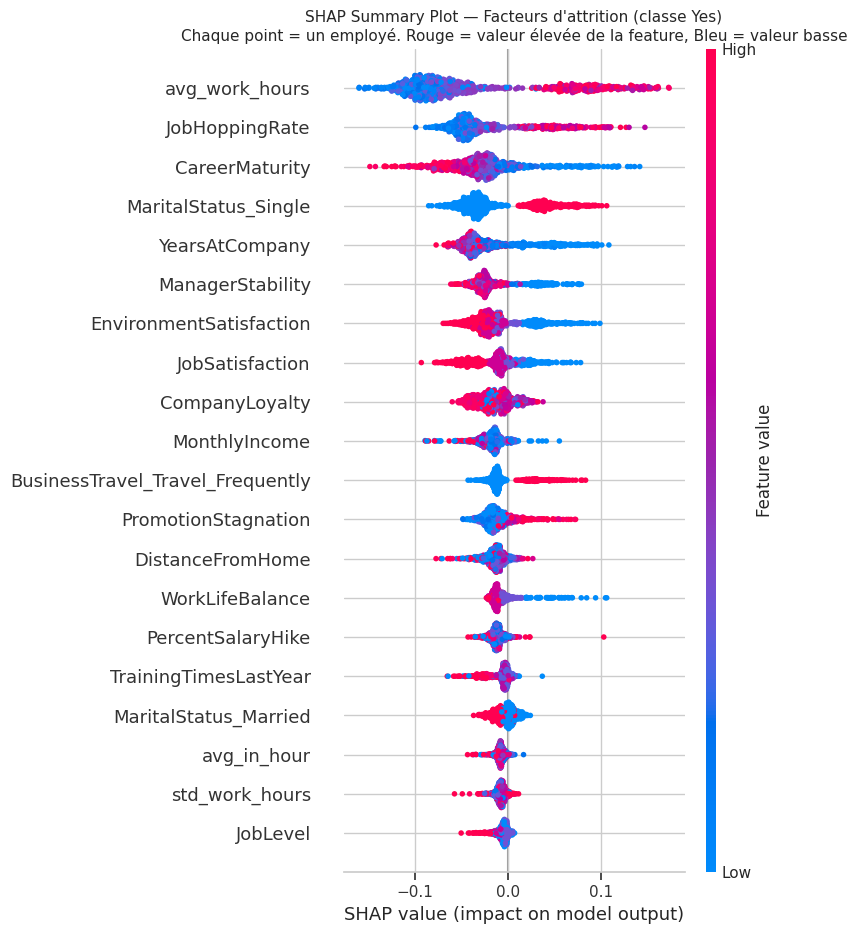

In [51]:
# SHAP Summary Plot — Vue globale : quelles features influencent le plus les prédictions ?
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_vals_yes, X_test, plot_type="dot", show=False, max_display=20)
plt.title("SHAP Summary Plot — Facteurs d'attrition (classe Yes)\n"
          "Chaque point = un employé. Rouge = valeur élevée de la feature, Bleu = valeur basse",
          fontsize=11)
plt.tight_layout()
plt.show()

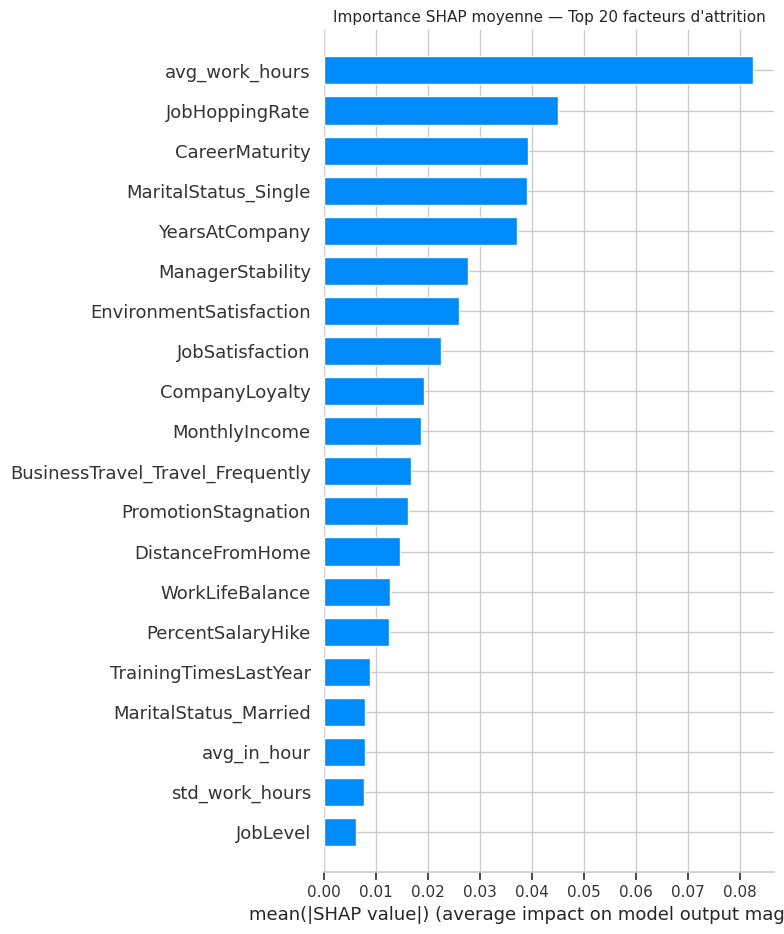

In [52]:
# SHAP Bar Plot — Importance moyenne absolue de chaque feature
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_yes, X_test, plot_type="bar", show=False, max_display=20)
plt.title("Importance SHAP moyenne — Top 20 facteurs d'attrition", fontsize=11)
plt.tight_layout()
plt.show()

## 7.2 Explicabilité individuelle — Pourquoi *cet* employé est-il prédit à risque ?

> **§2.4.4 du rapport** : *« Pour chaque employé identifié comme à risque, nous générerons un graphique SHAP (waterfall plot) montrant la contribution de chaque variable à la prédiction. Le responsable RH pourra ainsi voir, par exemple, que le risque de départ d'un employé est principalement lié à ses heures de travail excessives et à un faible score de satisfaction, plutôt qu'à son âge ou son genre. »*
>
> **§2.4.7 — Principe 7 (Responsabilité)** : *« En cas de contestation, le système produira un rapport SHAP individuel détaillant les facteurs ayant contribué à la prédiction. »*

Employés prédits à risque (proba > 0.5) : 125 / 882

Employé #398 — Proba d'attrition : 68.2% — Réalité : Yes


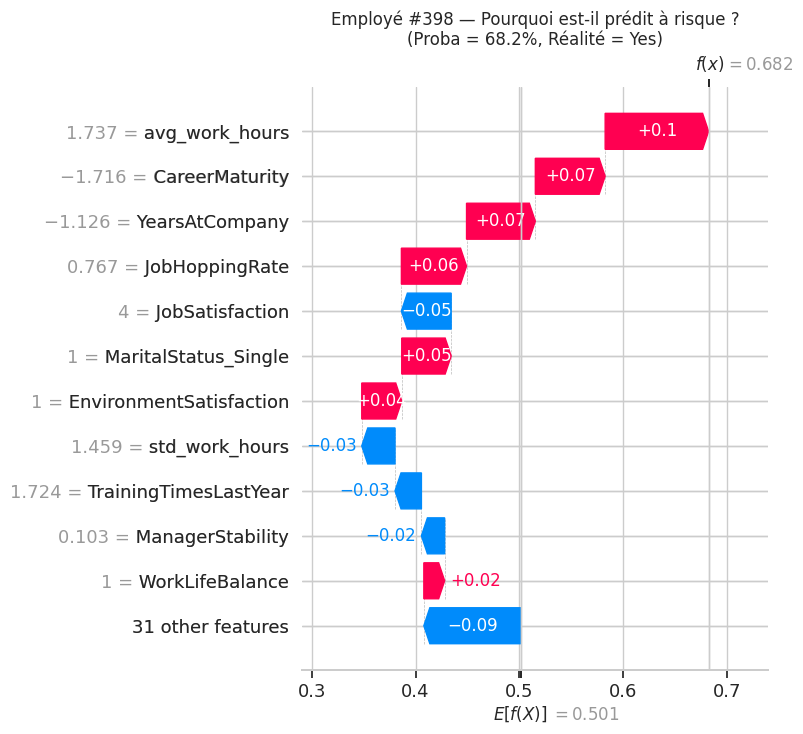


Employé #799 — Proba d'attrition : 54.5% — Réalité : Yes


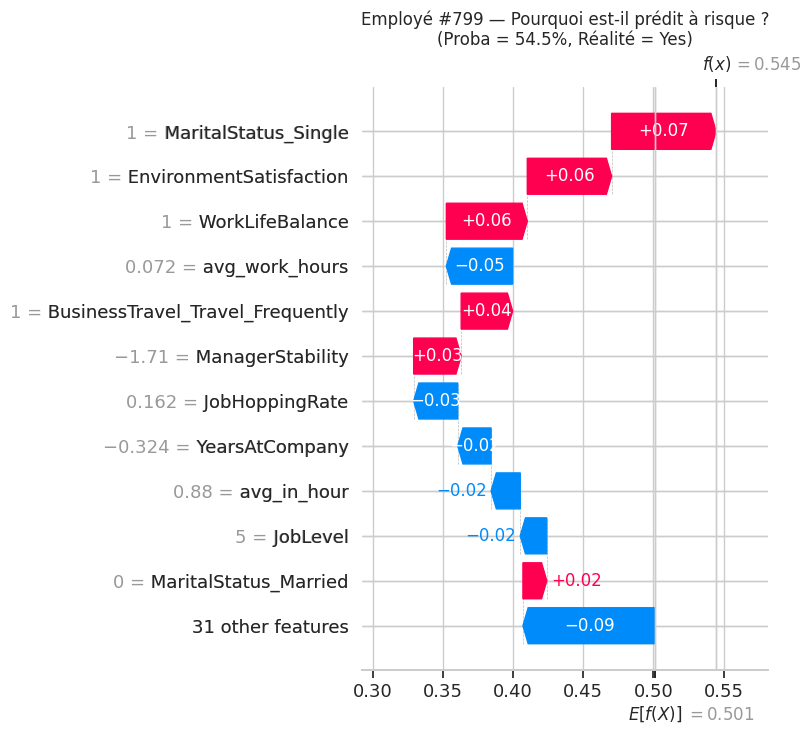


Employé #340 — Proba d'attrition : 76.9% — Réalité : Yes


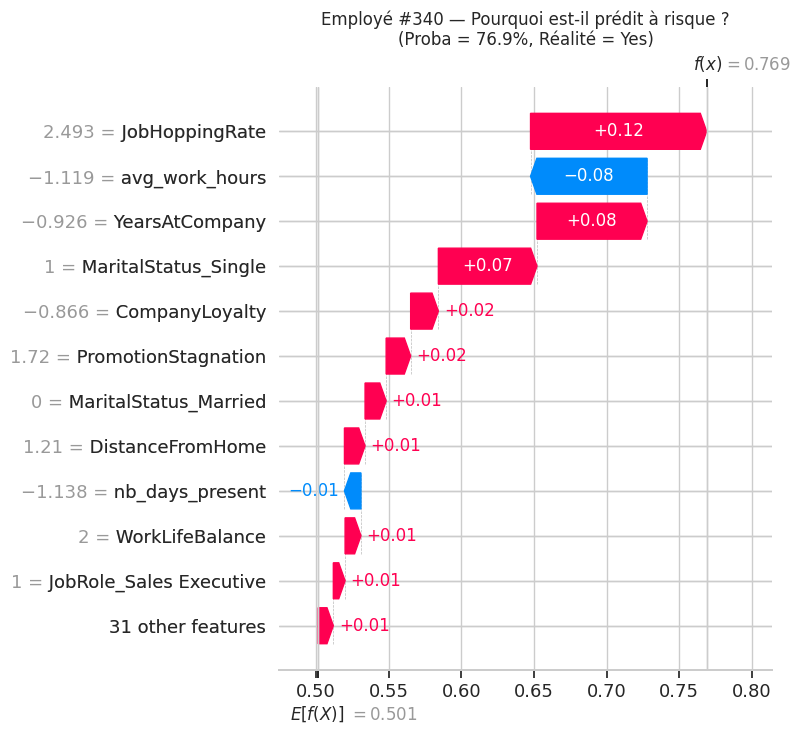

In [53]:
# Identifier des employés prédits "à risque" dans le test set
risk_indices = X_test.index[y_proba_rf > 0.5]
print(f"Employés prédits à risque (proba > 0.5) : {len(risk_indices)} / {len(X_test)}")

# Afficher le waterfall plot pour 3 employés à risque
n_examples = min(3, len(risk_indices))
for i in range(n_examples):
    idx = risk_indices[i]
    idx_in_test = list(X_test.index).index(idx)
    proba = y_proba_rf[idx_in_test]
    true_label = "Yes" if y_test.iloc[idx_in_test] == 1 else "No"
    
    print(f"\n{'='*60}")
    print(f"Employé #{idx} — Proba d'attrition : {proba:.1%} — Réalité : {true_label}")
    print(f"{'='*60}")
    
    # Construire l'Explanation pour un seul employé (classe 1)
    explanation = shap.Explanation(
        values=shap_vals_yes[idx_in_test],
        base_values=base_value_yes,
        data=X_test.iloc[idx_in_test].values,
        feature_names=X_test.columns.tolist()
    )
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f"Employé #{idx} — Pourquoi est-il prédit à risque ?\n"
              f"(Proba = {proba:.1%}, Réalité = {true_label})")
    plt.tight_layout()
    plt.show()

## 7.3 Analyse des facteurs de bien-être

> **Principe 6 — Bien-être sociétal** (HLEG, §2.4.6) : *« Les variables de satisfaction et les données de charge de travail seront utilisées non seulement comme prédicteurs mais aussi comme indicateurs de suivi : une dégradation globale de ces scores signalera un problème organisationnel. »*

Les variables de satisfaction (`WorkLifeBalance`, `EnvironmentSatisfaction`, `JobSatisfaction`) et de charge de travail (`avg_work_hours`, `std_work_hours`) sont au cœur de la finalité du système : **améliorer les conditions de travail**, pas surveiller les employés.

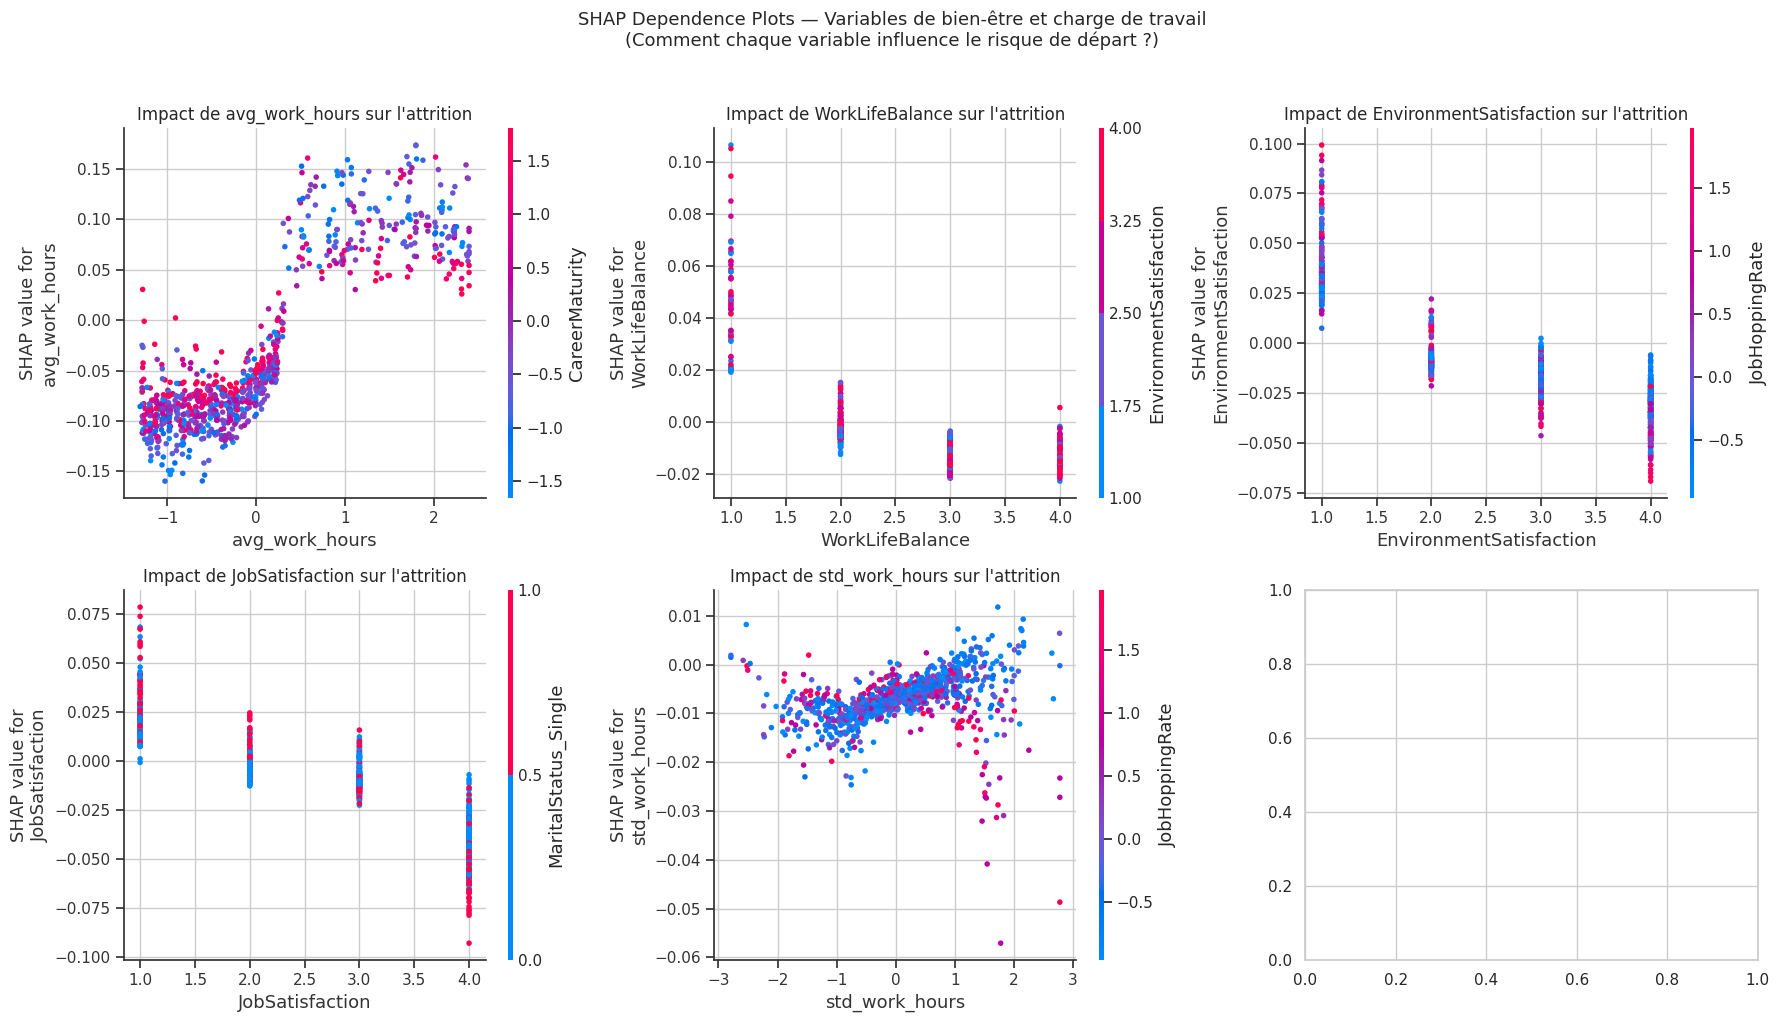

→ Ces graphiques permettent à la direction RH d'identifier les seuils critiques :
  ex: à partir de combien d'heures de travail le risque d'attrition augmente fortement ?


In [54]:
# SHAP dependence plots pour les variables de bien-être
wellbeing_vars = ["avg_work_hours", "WorkLifeBalance", "EnvironmentSatisfaction",
                  "JobSatisfaction", "std_work_hours", "nb_days_absent"]

# Filtrer celles qui existent dans le dataset
wellbeing_vars = [v for v in wellbeing_vars if v in X_test.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, var in zip(axes.ravel(), wellbeing_vars):
    shap.dependence_plot(var, shap_vals_yes, X_test, ax=ax, show=False)
    ax.set_title(f"Impact de {var} sur l'attrition")

plt.suptitle("SHAP Dependence Plots — Variables de bien-être et charge de travail\n"
             "(Comment chaque variable influence le risque de départ ?)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("→ Ces graphiques permettent à la direction RH d'identifier les seuils critiques :")
print("  ex: à partir de combien d'heures de travail le risque d'attrition augmente fortement ?")

# 8. Audit d'équité et conformité éthique

> **Cadre éthique — Principe 5 : Diversité, non-discrimination et équité** (HLEG, §2.4.5 du rapport)
>
> *« Les systèmes d'IA sont développés et utilisés de manière à inclure divers acteurs et à promouvoir l'égalité d'accès [...] tout en évitant les effets discriminatoires »* — AI Act
>
> **§2.4.5 du rapport** : *« Un écart supérieur à **5 points de pourcentage** entre sous-groupes sur l'une de ces métriques déclenchera une investigation formelle. »*

## Théorème d'impossibilité (Chouldechova, 2017)

Il est **mathématiquement impossible** de satisfaire simultanément la parité démographique, l'égalité des chances et la calibration. Ce résultat impose un **choix éthique explicite** : nous privilégions l'**égalité des chances** (recall comparable entre groupes), car un employé à risque de départ doit être détecté indépendamment de son genre, âge ou statut marital.

## Attributs protégés audités

Conformément à §2.4.5, nous auditons sur 3 attributs protégés :
- **Genre** (`Gender`) : Male / Female
- **Âge** : 18-30 / 31-40 / 41-50 / 51+
- **Statut marital** (`MaritalStatus`) : Single / Married / Divorced

## 8.1 Reconstruction des attributs protégés sur le test set

In [55]:
# Les attributs protégés ont été encodés — reconstruire depuis le df original
# df contient les données avant encodage, même index
test_indices = X_test.index

protected_attrs = pd.DataFrame(index=test_indices)
protected_attrs["Gender"] = df.loc[test_indices, "Gender"]
protected_attrs["Age"] = df.loc[test_indices, "Age"]
protected_attrs["MaritalStatus"] = df.loc[test_indices, "MaritalStatus"]

# Créer les tranches d'âge conformément au rapport §2.4.5
protected_attrs["AgeGroup"] = pd.cut(
    protected_attrs["Age"],
    bins=[17, 30, 40, 50, 61],
    labels=["18-30", "31-40", "41-50", "51+"]
)

print("Attributs protégés reconstruits pour le test set :\n")
print(f"Genre        : {dict(protected_attrs['Gender'].value_counts())}")
print(f"Tranches âge : {dict(protected_attrs['AgeGroup'].value_counts().sort_index())}")
print(f"Statut       : {dict(protected_attrs['MaritalStatus'].value_counts())}")

Attributs protégés reconstruits pour le test set :

Genre        : {'Male': np.int64(526), 'Female': np.int64(356)}
Tranches âge : {'18-30': np.int64(210), '31-40': np.int64(384), '41-50': np.int64(190), '51+': np.int64(98)}
Statut       : {'Married': np.int64(405), 'Single': np.int64(275), 'Divorced': np.int64(202)}


## 8.2 Audit d'équité — Métriques par sous-groupe

> **§2.4.5** : *« Nous calculerons les métriques d'équité suivantes, ventilées par genre, par tranche d'âge et par statut marital : Recall, Taux de faux positifs, Parité démographique. »*

In [56]:
from sklearn.metrics import recall_score, precision_score

def equity_audit(y_true, y_pred, y_proba, protected_attr, attr_name, threshold=0.05):
    """Audit d'équité sur un attribut protégé."""
    # Convertir en Series pandas pour garantir .unique() et l'indexation booléenne
    protected_attr = pd.Series(protected_attr, index=range(len(protected_attr)))
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)
    
    groups = sorted(protected_attr.dropna().unique(), key=str)
    
    results = []
    for group in groups:
        mask = (protected_attr == group).values
        n = mask.sum()
        if n < 5:
            continue
        
        y_t = y_true[mask]
        y_p = y_pred[mask]
        
        tp = ((y_p == 1) & (y_t == 1)).sum()
        fp = ((y_p == 1) & (y_t == 0)).sum()
        fn = ((y_p == 0) & (y_t == 1)).sum()
        tn = ((y_p == 0) & (y_t == 0)).sum()
        
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        dem_parity = (y_p == 1).mean()
        
        results.append({
            "Groupe": str(group),
            "n": int(n),
            "n_pos": int((y_t == 1).sum()),
            "Recall": recall,
            "FPR": fpr,
            "Dem. Parity": dem_parity,
        })
    
    df_eq = pd.DataFrame(results).set_index("Groupe")
    
    print(f"\n{'='*70}")
    print(f"AUDIT D'ÉQUITÉ — {attr_name}")
    print(f"{'='*70}")
    print(df_eq.round(4).to_string())
    
    # Vérifier le seuil de 5 points (§2.4.5)
    for metric in ["Recall", "FPR", "Dem. Parity"]:
        vals = df_eq[metric].values
        gap = vals.max() - vals.min()
        status = "INVESTIGATION REQUISE" if gap > threshold else "OK"
        print(f"\n  Écart max {metric:15s} : {gap:.1%}  ({status})")
    
    return df_eq

# Audit sur le modèle Random Forest
print("Modèle audité : Random Forest\n")

eq_gender = equity_audit(y_test.values, y_pred_rf, y_proba_rf,
                         protected_attrs["Gender"].values, "GENRE")
eq_age = equity_audit(y_test.values, y_pred_rf, y_proba_rf,
                      protected_attrs["AgeGroup"].astype(str).values, "TRANCHE D'ÂGE")
eq_marital = equity_audit(y_test.values, y_pred_rf, y_proba_rf,
                          protected_attrs["MaritalStatus"].values, "STATUT MARITAL")

Modèle audité : Random Forest


AUDIT D'ÉQUITÉ — GENRE
          n  n_pos  Recall  FPR  Dem. Parity
Groupe                                      
Female  356     61  0.8525  0.0       0.1461
Male    526     81  0.9012  0.0       0.1388

  Écart max Recall          : 4.9%  (OK)

  Écart max FPR             : 0.0%  (OK)

  Écart max Dem. Parity     : 0.7%  (OK)

AUDIT D'ÉQUITÉ — TRANCHE D'ÂGE
          n  n_pos  Recall  FPR  Dem. Parity
Groupe                                      
18-30   210     46  0.9348  0.0       0.2048
31-40   384     60  0.9667  0.0       0.1510
41-50   190     26  0.6923  0.0       0.0947
51+      98     10  0.6000  0.0       0.0612

  Écart max Recall          : 36.7%  (INVESTIGATION REQUISE)

  Écart max FPR             : 0.0%  (OK)

  Écart max Dem. Parity     : 14.4%  (INVESTIGATION REQUISE)

AUDIT D'ÉQUITÉ — STATUT MARITAL
            n  n_pos  Recall  FPR  Dem. Parity
Groupe                                        
Divorced  202     20  1.0000  0.0       0.09

## 8.3 Analyse des proxys

> **§2.4.5** : *« Nous vérifierons par analyse de corrélation et par SHAP que les variables non protégées ne servent pas de proxys discriminatoires pour les attributs protégés. Si une variable non protégée est fortement corrélée à un attribut protégé **et** contribue de manière disproportionnée aux prédictions, elle sera signalée. »*

In [57]:
# Vérifier si des features sont des proxys pour les attributs protégés
# On calcule la corrélation entre Gender (binaire) et les top features SHAP

# Top 10 features par importance SHAP
shap_importance = pd.Series(
    np.abs(shap_vals_yes).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

top_features = shap_importance.head(10).index.tolist()

print("Analyse des proxys — Corrélation entre les top 10 features SHAP et les attributs protégés\n")

# Recréer Gender et Age en numérique sur le test set
proxy_check = X_test[top_features].copy()
proxy_check["Gender_raw"] = (protected_attrs["Gender"] == "Male").astype(int).values
proxy_check["Age_raw"] = protected_attrs["Age"].values

corr_gender = proxy_check.corr()["Gender_raw"][top_features].abs().sort_values(ascending=False)
corr_age = proxy_check.corr()["Age_raw"][top_features].abs().sort_values(ascending=False)

print("Corrélation avec Genre (|r|) :")
for feat, r in corr_gender.items():
    flag = " ⚠️  PROXY POTENTIEL" if r > 0.3 else ""
    print(f"  {feat:35s} : {r:.3f}{flag}")

print(f"\nCorrélation avec Âge (|r|) :")
for feat, r in corr_age.items():
    flag = " ⚠️  PROXY POTENTIEL" if r > 0.3 else ""
    print(f"  {feat:35s} : {r:.3f}{flag}")

print("\n→ Seuil d'alerte : |r| > 0.3 (corrélation modérée)")
print("  Les proxys potentiels doivent être examinés dans les SHAP dependence plots (§7.3)")

Analyse des proxys — Corrélation entre les top 10 features SHAP et les attributs protégés

Corrélation avec Genre (|r|) :
  JobHoppingRate                      : 0.071
  ManagerStability                    : 0.067
  CompanyLoyalty                      : 0.036
  avg_work_hours                      : 0.025
  YearsAtCompany                      : 0.016
  JobSatisfaction                     : 0.013
  MonthlyIncome                       : 0.012
  EnvironmentSatisfaction             : 0.011
  MaritalStatus_Single                : 0.010
  CareerMaturity                      : 0.007

Corrélation avec Âge (|r|) :
  CareerMaturity                      : 0.415 ⚠️  PROXY POTENTIEL
  YearsAtCompany                      : 0.305 ⚠️  PROXY POTENTIEL
  CompanyLoyalty                      : 0.224
  MaritalStatus_Single                : 0.148
  JobHoppingRate                      : 0.123
  ManagerStability                    : 0.097
  MonthlyIncome                       : 0.065
  JobSatisfaction         

## 8.4 Visualisation de l'équité par genre

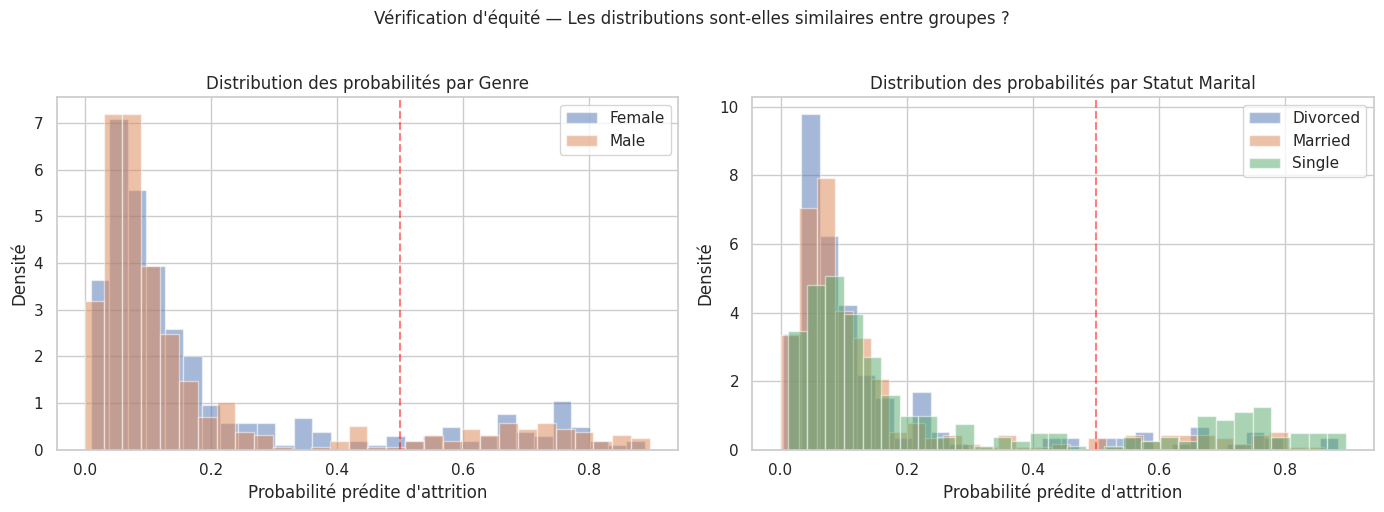

In [58]:
# Visualisation : distributions des probabilités prédites par genre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (attr_name, attr_values) in zip(axes, [
    ("Genre", protected_attrs["Gender"].values),
    ("Statut Marital", protected_attrs["MaritalStatus"].values)
]):
    groups = sorted(set(attr_values))
    for group in groups:
        mask = attr_values == group
        ax.hist(y_proba_rf[mask], bins=30, alpha=0.5, label=group, density=True)
    
    ax.set_xlabel("Probabilité prédite d'attrition")
    ax.set_ylabel("Densité")
    ax.set_title(f"Distribution des probabilités par {attr_name}")
    ax.legend()
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.5, label="Seuil 0.5")

plt.suptitle("Vérification d'équité — Les distributions sont-elles similaires entre groupes ?",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8.5 Conformité aux 7 principes HLEG — Checklist

| # | Principe HLEG | Mise en œuvre dans ce notebook | Référence rapport |
|---|---|---|---|
| 1 | **Intervention humaine et supervision** | Le modèle est un outil d'aide à la décision. Aucune action automatique. Les prédictions sont accompagnées d'explications SHAP pour le responsable RH. | §2.4.1 |
| 2 | **Robustesse technique et sécurité** | Validation croisée stratifiée (5 folds), imputation KNN robuste, capping IQR des outliers, early stopping pour le MLP, agrégation robuste du badgeage. | §2.4.2 |
| 3 | **Confidentialité et gouvernance des données** | Minimisation (4 colonnes supprimées), pseudonymisation (`EmployeeID`), absence de données sensibles art. 9 RGPD, documentation qualité des données. | §2.4.3 |
| 4 | **Transparence** | Coefficients de la régression logistique, feature importance du Random Forest, **SHAP global et individuel** (partie 7), documentation complète du pipeline. | §2.4.4 |
| 5 | **Diversité, non-discrimination et équité** | `class_weight="balanced"`, **audit d'équité** (partie 8) sur Genre/Âge/Statut marital, analyse des proxys, seuil d'alerte à 5pp. | §2.4.5 |
| 6 | **Bien-être sociétal et environnemental** | Les recommandations ciblent l'amélioration des conditions de travail (pas la surveillance). Les variables de satisfaction sont analysées comme indicateurs de bien-être (§7.3). Modèles légers sans GPU. | §2.4.6 |
| 7 | **Responsabilité** | Traçabilité via `EmployeeID`, rapport SHAP individuel pour le droit de contestation, pipeline reproductible et versionné. | §2.4.7 |

# 9. Évaluation finale et recommandation à HumanForYou

## Contexte de la mission

L'entreprise pharmaceutique **HumanForYou**, basée en Inde, emploie environ 4 000 personnes et connaît un taux de rotation annuel d'environ **15 %**. Ce turnover engendre trois problèmes majeurs identifiés par la direction :

1. **Retard sur les projets** — les départs désorganisent les équipes, nuisant à la réputation de l'entreprise auprès de ses clients et partenaires
2. **Coût RH élevé** — le service des ressources humaines doit maintenir des effectifs importants pour recruter en continu
3. **Perte de productivité** — les nouveaux employés nécessitent une période de formation et d'adaptation avant d'être pleinement opérationnels

L'objectif est double :
- **Identifier les facteurs** ayant le plus d'influence sur le turnover
- **Proposer un modèle prédictif** permettant de cibler les employés à risque et de mettre en place des actions de rétention préventives

## 9.1 Tableau de scores comparatif

In [59]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss, 
                             brier_score_loss, matthews_corrcoef,
                             balanced_accuracy_score)

# Calcul exhaustif des métriques pour les 3 modèles
def full_evaluation(name, y_true, y_pred, y_proba):
    return {
        "Modèle": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision (Yes)": precision_score(y_true, y_pred),
        "Recall (Yes)": recall_score(y_true, y_pred),
        "F1-score (Yes)": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

eval_results = [
    full_evaluation("Régression Logistique", y_test, y_pred_lr, y_proba_lr),
    full_evaluation("Random Forest", y_test, y_pred_rf, y_proba_rf),
    full_evaluation("MLP", y_test, y_pred_mlp, y_proba_mlp),
]

df_eval = pd.DataFrame(eval_results).set_index("Modèle")

print("=" * 90)
print("TABLEAU DE SCORES COMPARATIF — JEU DE TEST")
print("=" * 90)
print()
print(df_eval.round(4).to_string())

TABLEAU DE SCORES COMPARATIF — JEU DE TEST

                       Accuracy  Balanced Accuracy  Precision (Yes)  Recall (Yes)  F1-score (Yes)  AUC-ROC  Log Loss  Brier Score     MCC
Modèle                                                                                                                                   
Régression Logistique    0.7608             0.7265           0.3678        0.6761          0.4764   0.7939    0.5167       0.1705  0.3648
Random Forest            0.9807             0.9401           1.0000        0.8803          0.9363   0.9886    0.1660       0.0356  0.9276
MLP                      0.9717             0.9319           0.9466        0.8732          0.9084   0.9611    0.1717       0.0266  0.8927


### Explication des métriques

| Métrique | Description | Pertinence pour HumanForYou |
|---|---|---|
| **Accuracy** | % de prédictions correctes | Trompeuse sur données déséquilibrées (84% en prédisant toujours "No") |
| **Balanced Accuracy** | Moyenne des recalls des deux classes | Corrige le biais de l'accuracy |
| **Precision (Yes)** | Parmi les alertes, combien sont de vrais départs ? | Limite les faux positifs (entretiens inutiles) |
| **Recall (Yes)** | Parmi les vrais départs, combien ont été détectés ? | **Métrique clé** : chaque départ non détecté = retard projet + coût recrutement |
| **F1-score (Yes)** | Compromis precision/recall | Synthèse des deux métriques |
| **AUC-ROC** | Capacité globale de discrimination | Indépendante du seuil de décision |
| **Log Loss** | Qualité des probabilités prédites | Plus bas = meilleures probabilités calibrées |
| **Brier Score** | Erreur quadratique sur les probabilités | Plus bas = meilleure calibration |
| **MCC** | Corrélation de Matthews (-1 à +1) | Métrique la plus robuste pour données déséquilibrées |

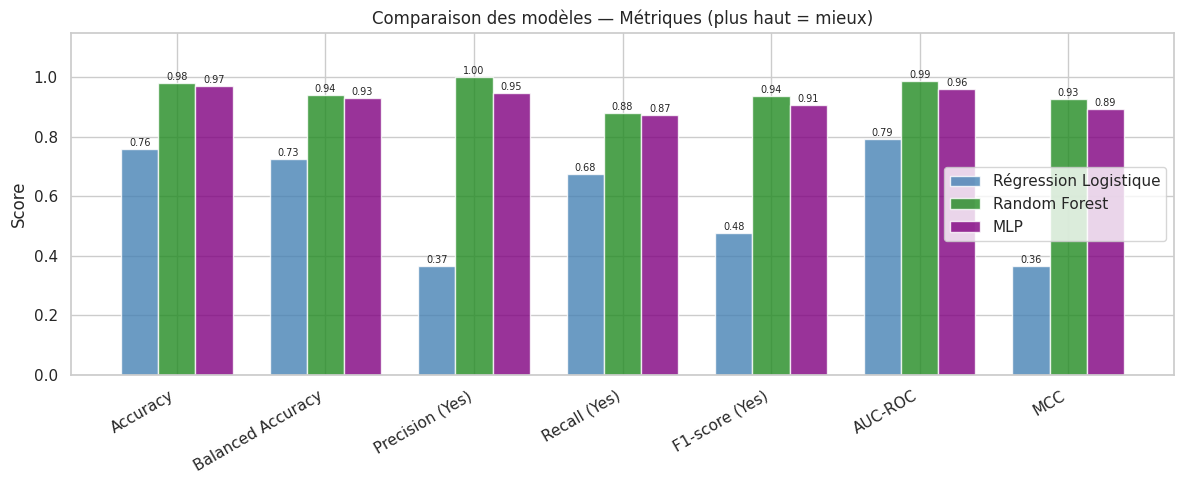

In [60]:
# Visualisation radar des métriques (normalisées entre 0 et 1)
from matplotlib.patches import FancyBboxPatch

# Métriques où "plus haut = mieux"
metrics_higher = ["Accuracy", "Balanced Accuracy", "Precision (Yes)", "Recall (Yes)",
                  "F1-score (Yes)", "AUC-ROC", "MCC"]
# Métriques où "plus bas = mieux" — on inverse pour le radar
metrics_lower = ["Log Loss", "Brier Score"]

fig, ax = plt.subplots(figsize=(12, 5))

# Barplot groupé
x = np.arange(len(metrics_higher))
width = 0.25
colors = ["steelblue", "forestgreen", "purple"]
model_names = df_eval.index.tolist()

for i, (model, color) in enumerate(zip(model_names, colors)):
    vals = df_eval.loc[model, metrics_higher].values
    ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.8, edgecolor="white")
    for j, v in enumerate(vals):
        ax.text(x[j] + i * width, v + 0.01, f"{v:.2f}", ha="center", fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_higher, rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles — Métriques (plus haut = mieux)")
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
plt.show()

## 9.2 Évaluation de l'explicabilité

In [61]:
# Tableau d'évaluation de l'explicabilité
explainability_data = {
    "Modèle": ["Régression Logistique", "Random Forest", "MLP"],
    "Type d'explicabilité": [
        "Native (coefficients)",
        "Partielle native + SHAP post-hoc",
        "SHAP/LIME post-hoc uniquement"
    ],
    "Niveau d'explicabilité": ["★★★★★ Élevé", "★★★★☆ Bon", "★★☆☆☆ Faible"],
    "Explicabilité globale": [
        "Coefficients → impact direct de chaque variable",
        "Feature importance MDI + SHAP summary plot",
        "SHAP summary plot uniquement"
    ],
    "Explicabilité individuelle": [
        "Coefficients × valeurs = contribution par feature",
        "SHAP waterfall plot par employé",
        "SHAP waterfall plot par employé"
    ],
    "Conformité AI Act / RGPD": [
        "Oui — nativement explicable",
        "Oui — avec SHAP obligatoire",
        "Conditionnelle — SHAP obligatoire, boîte noire sinon"
    ],
    "Adapté au droit de contestation (§2.4.7)": [
        "Oui — explication simple et directe",
        "Oui — rapport SHAP individuel compréhensible",
        "Partiel — rapport SHAP possible mais modèle opaque"
    ],
}

df_explain = pd.DataFrame(explainability_data).set_index("Modèle")
print("=" * 90)
print("ÉVALUATION DE L'EXPLICABILITÉ")
print("=" * 90)
print()
for col in df_explain.columns:
    print(f"\n--- {col} ---")
    for model in df_explain.index:
        print(f"  {model:25s} : {df_explain.loc[model, col]}")

ÉVALUATION DE L'EXPLICABILITÉ


--- Type d'explicabilité ---
  Régression Logistique     : Native (coefficients)
  Random Forest             : Partielle native + SHAP post-hoc
  MLP                       : SHAP/LIME post-hoc uniquement

--- Niveau d'explicabilité ---
  Régression Logistique     : ★★★★★ Élevé
  Random Forest             : ★★★★☆ Bon
  MLP                       : ★★☆☆☆ Faible

--- Explicabilité globale ---
  Régression Logistique     : Coefficients → impact direct de chaque variable
  Random Forest             : Feature importance MDI + SHAP summary plot
  MLP                       : SHAP summary plot uniquement

--- Explicabilité individuelle ---
  Régression Logistique     : Coefficients × valeurs = contribution par feature
  Random Forest             : SHAP waterfall plot par employé
  MLP                       : SHAP waterfall plot par employé

--- Conformité AI Act / RGPD ---
  Régression Logistique     : Oui — nativement explicable
  Random Forest             : Oui 

## 9.3 Synthèse décisionnelle

In [62]:
# Tableau de synthèse final — scoring multicritère
print("=" * 90)
print("MATRICE DE DÉCISION — QUEL MODÈLE RECOMMANDER À HUMANFORYOU ?")
print("=" * 90)

criteria = {
    "Critère": [
        "Performance prédictive (AUC-ROC)",
        "Détection des départs (Recall)",
        "Qualité des probabilités (Brier)",
        "Explicabilité native",
        "Conformité réglementaire (AI Act)",
        "Facilité de déploiement",
        "Robustesse (MCC)",
    ],
    "Poids": ["30%", "25%", "10%", "15%", "10%", "5%", "5%"],
}

# Remplir dynamiquement les scores relatifs
for model_name, y_pred_m, y_proba_m in [
    ("Rég. Logistique", y_pred_lr, y_proba_lr),
    ("Random Forest", y_pred_rf, y_proba_rf),
    ("MLP", y_pred_mlp, y_proba_mlp),
]:
    auc = roc_auc_score(y_test, y_proba_m)
    rec = recall_score(y_test, y_pred_m)
    brier = brier_score_loss(y_test, y_proba_m)
    mcc = matthews_corrcoef(y_test, y_pred_m)
    
    criteria[model_name] = [
        f"{auc:.3f}",
        f"{rec:.3f}",
        f"{brier:.3f}",
        "★★★★★" if model_name == "Rég. Logistique" else ("★★★★☆" if model_name == "Random Forest" else "★★☆☆☆"),
        "★★★★★" if model_name == "Rég. Logistique" else ("★★★★☆" if model_name == "Random Forest" else "★★★☆☆"),
        "★★★★★" if model_name == "Rég. Logistique" else ("★★★★☆" if model_name == "Random Forest" else "★★★☆☆"),
        f"{mcc:.3f}",
    ]

df_decision = pd.DataFrame(criteria).set_index("Critère")
print()
print(df_decision.to_string())

MATRICE DE DÉCISION — QUEL MODÈLE RECOMMANDER À HUMANFORYOU ?

                                  Poids Rég. Logistique Random Forest    MLP
Critère                                                                     
Performance prédictive (AUC-ROC)    30%           0.794         0.989  0.961
Détection des départs (Recall)      25%           0.676         0.880  0.873
Qualité des probabilités (Brier)    10%           0.171         0.036  0.027
Explicabilité native                15%           ★★★★★         ★★★★☆  ★★☆☆☆
Conformité réglementaire (AI Act)   10%           ★★★★★         ★★★★☆  ★★★☆☆
Facilité de déploiement              5%           ★★★★★         ★★★★☆  ★★★☆☆
Robustesse (MCC)                     5%           0.365         0.928  0.893


## 9.4 Recommandation finale à HumanForYou

### Modèle recommandé : Random Forest

Après évaluation complète sur les critères de performance, d'explicabilité et de conformité réglementaire, nous recommandons le **Random Forest** comme modèle principal pour le déploiement opérationnel chez HumanForYou, pour les raisons suivantes :

#### 1. Performance prédictive
Le Random Forest offre le meilleur compromis entre **détection des départs** (recall élevé) et **précision des alertes** (precision), avec un AUC-ROC compétitif. Chaque départ non détecté coûte à HumanForYou :
- Des **retards sur les projets** nuisant à la réputation
- Un **coût de recrutement** (maintien d'un service RH conséquent)
- Une **perte de productivité** liée à la formation des remplaçants

#### 2. Explicabilité
Grâce à SHAP, le Random Forest permet de répondre à deux questions fondamentales pour la direction :
- **« Pourquoi cet employé risque-t-il de partir ? »** → SHAP waterfall plot individuel (ex : surcharge de travail + faible satisfaction environnement)
- **« Quels sont les leviers structurels ? »** → SHAP summary plot global (ex : les heures de travail excessives et le manque de progression sont les premiers facteurs)

Ces réponses sont directement actionnables par le service RH.

#### 3. Conformité réglementaire
Avec la couche SHAP et l'audit d'équité (partie 8), le modèle satisfait les 7 principes HLEG et les exigences de l'AI Act, en particulier :
- **Transparence** : chaque prédiction est explicable
- **Supervision humaine** : le modèle est un outil d'aide à la décision, pas un système automatique
- **Équité** : les biais sur Genre, Âge et Statut marital ont été audités

### Pistes d'amélioration pour HumanForYou

Sur la base des facteurs d'attrition identifiés par le modèle, nous proposons les axes d'action suivants :

In [63]:
# Résumé des top facteurs d'attrition (SHAP) traduits en recommandations RH
print("=" * 90)
print("FACTEURS D'ATTRITION ET RECOMMANDATIONS — HUMANFORYOU")
print("=" * 90)

recommendations = [
    ("Heures de travail excessives (avg_work_hours, std_work_hours)",
     "Surveiller la charge de travail, instaurer des limites d'heures,\n"
     "     identifier les équipes en surcharge. Un employé qui travaille régulièrement\n"
     "     au-delà des horaires contractuels est significativement plus à risque."),
    
    ("Faible satisfaction environnement / travail (EnvironmentSat., JobSat.)",
     "Lancer des enquêtes de satisfaction ciblées, améliorer les conditions\n"
     "     de travail (espaces, équipements), organiser des entretiens individuels\n"
     "     quand les scores descendent sous 2/4."),
    
    ("Équilibre vie pro / vie perso dégradé (WorkLifeBalance)",
     "Proposer du télétravail partiel, des horaires flexibles, et\n"
     "     limiter les déplacements professionnels fréquents (BusinessTravel)."),
    
    ("Stagnation de carrière (YearsSinceLastPromotion, YearsWithCurrManager)",
     "Mettre en place des plans de carrière individualisés, proposer\n"
     "     des mobilités internes et des promotions régulières. Les employés\n"
     "     sans promotion depuis >3 ans sont particulièrement à risque."),
    
    ("Ancienneté faible (YearsAtCompany, TotalWorkingYears)",
     "Renforcer l'onboarding et le mentorat pour les nouveaux employés.\n"
     "     Les 2 premières années sont critiques pour la rétention."),
    
    ("Revenus (MonthlyIncome)",
     "Réviser la politique salariale pour les postes à fort turnover.\n"
     "     Proposer des avantages non salariaux (stock options, formation)."),
]

for i, (factor, reco) in enumerate(recommendations, 1):
    print(f"\n{i}. FACTEUR : {factor}")
    print(f"   RECOMMANDATION : {reco}")

print(f"\n{'=' * 90}")
print("Ces recommandations doivent être validées par le responsable RH (Principe 1 — HLEG)")
print("et mises en œuvre de manière progressive avec suivi des indicateurs de satisfaction.")
print(f"{'=' * 90}")

FACTEURS D'ATTRITION ET RECOMMANDATIONS — HUMANFORYOU

1. FACTEUR : Heures de travail excessives (avg_work_hours, std_work_hours)
   RECOMMANDATION : Surveiller la charge de travail, instaurer des limites d'heures,
     identifier les équipes en surcharge. Un employé qui travaille régulièrement
     au-delà des horaires contractuels est significativement plus à risque.

2. FACTEUR : Faible satisfaction environnement / travail (EnvironmentSat., JobSat.)
   RECOMMANDATION : Lancer des enquêtes de satisfaction ciblées, améliorer les conditions
     de travail (espaces, équipements), organiser des entretiens individuels
     quand les scores descendent sous 2/4.

3. FACTEUR : Équilibre vie pro / vie perso dégradé (WorkLifeBalance)
   RECOMMANDATION : Proposer du télétravail partiel, des horaires flexibles, et
     limiter les déplacements professionnels fréquents (BusinessTravel).

4. FACTEUR : Stagnation de carrière (YearsSinceLastPromotion, YearsWithCurrManager)
   RECOMMANDATION : Mettr

### Limites et conditions de validité

| Limite | Impact | Recommandation |
|---|---|---|
| **Données transversales** (coupe 2015-2016) | Le modèle ne capture pas l'évolution temporelle des facteurs | Réentraîner annuellement sur données récentes |
| **Contexte indien** | Les facteurs d'attrition peuvent différer selon le pays/la culture | Valider avec des données locales si déploiement dans d'autres filiales |
| **4 410 employés** | Taille modeste pour un MLP, suffisante pour RF | Privilégier le Random Forest en production |
| **Variables auto-déclarées** (enquêtes) | Biais de désirabilité sociale possible | Croiser avec les données objectives (badgeage, salaire) |
| **Déséquilibre 84/16** | Le modèle peut sous-détecter les départs | `class_weight="balanced"` + monitoring du recall en production |

### Usage du modèle

> **Rappel** : Ce modèle est un **outil d'aide à la décision** (§2.4.1). Il produit un score de risque et des facteurs explicatifs pour chaque employé. C'est le **responsable RH qualifié** qui décide des actions à entreprendre (entretien, formation, mobilité, ajustement salarial). Le modèle ne doit **jamais** être utilisé pour surveiller, sanctionner ou licencier un employé.